<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/DA/USDA_FOOD_DATABASE_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**USDA FOOD DATABASE ANALYSIS**

#**1.Định nghĩa vấn đề**

**a) Mô tả**
  + Phạm vi: Cơ sở dữ liệu dinh dưỡng thực phẩm toàn diện của Bộ Nông nghiệp Hoa Kỳ (USDA)
  + Kích thước: 6,636 loại thực phẩm với 375,176 bản ghi chất dinh dưỡng sau khi xử lý
  + Đặc điểm: Dữ liệu đa chiều về thành phần dinh dưỡng, định lượng phần ăn, và phân loại thực phẩm

**b) Dữ liệu vào**

***Thông tin cơ bản (Info DataFrame):***

  - id: ID duy nhất của thực phẩm (Int64)

  - description: Tên đầy đủ của thực phẩm (Object)

  - group: Nhóm thực phẩm chính (Object)

  - manufacturer: Nhà sản xuất (Object)

  - tags: Thẻ phân loại (Object)

***Thông tin dinh dưỡng (Nutrients DataFrame):***

  - id: ID thực phẩm liên kết (Int64)

  - value: Giá trị dinh dưỡng (Float64)

  - units: Đơn vị đo lường (Object)

  - description: Tên chất dinh dưỡng (Object)

  - group: Nhóm chất dinh dưỡng (Object)

***Thông tin định lượng (Portions):***

  - amount: Số lượng phần ăn (Float64)

  - unit: Đơn vị phần ăn (Object)

  - grams: Trọng lượng tương đương theo gram (Float64)


**c) Dữ liệu ra (Kết quả phân tích)**

**Các insight về dinh dưỡng và thực phẩm:**

- Phân bổ dinh dưỡng across các nhóm thực phẩm

- So sánh giá trị dinh dưỡng giữa các thực phẩm

- Mối quan hệ giữa các chất dinh dưỡng

- Xu hướng dinh dưỡng theo nhóm thực phẩm


#**2.Chuẩn bị dữ liệu**

##**2.1.Khai báo thư viện.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import json

##**2.2.Nạp dữ liệu.**

In [ ]:
url = "https://raw.githubusercontent.com/wesm/pydata-book/3rd-edition/datasets/usda_food/database.json"

db = pd.read_json(url)
display(db.head())

,id,description,tags,manufacturer,group,portions,nutrients
0,1008,"Cheese, caraway",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'oz', 'grams': 28.35}]","[{'value': 25.18, 'units': 'g', 'description':..."
1,1009,"Cheese, cheddar",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'cup, diced', 'grams': ...","[{'value': 24.9, 'units': 'g', 'description': ..."
2,1018,"Cheese, edam",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'oz', 'grams': 28.35}, ...","[{'value': 4.22, 'units': 'g', 'description': ..."
3,1019,"Cheese, feta",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'cup, crumbled', 'grams...","[{'value': 5.2, 'units': 'g', 'description': '..."
4,1028,"Cheese, mozzarella, part skim milk",[],,Dairy and Egg Products,"[{'amount': 1, 'unit': 'oz', 'grams': 28.35}]","[{'value': 3.27, 'units': 'g', 'description': ..."


In [ ]:
# In ra số lượng dòng dữ liệu trong DataFrame
len(db)

6636

##**2.3 Xử Lý Dữ Liệu Trước Khi Gộp (Merge)**
Trước khi gộp (merge) hai DataFrame info (thông tin thực phẩm) và nutrients (thành phần dinh dưỡng), cần xử lý dữ liệu để tránh lỗi và đảm bảo tính nhất quán.

###**2.3.1.TẠO INFO DATAFRAME - Thông tin cơ bản về thực phẩm**

In [ ]:
info_keys = ["description", "group", "id", "manufacturer"]
info = pd.DataFrame(db, columns=info_keys)

**Giải thích:**

- info_keys: Chọn 4 trường quan trọng từ dữ liệu gốc: description(mô tả), group, id, manufacturer(nhà sản xuất)

- Tạo DataFrame info chỉ chứa các trường này

**Kết quả:** Mỗi dòng là 1 thực phẩm với thông tin cơ bản

###**2.3.2.TẠO NUTRIENTS DATAFRAME - Ghép dữ liệu dinh dưỡng**

In [ ]:
nutrients = []
for index, rec in db.iterrows():  # Lặp qua từng dòng trong db
    fnuts = pd.DataFrame(rec["nutrients"])  # Biến nutrients thành DataFrame nhỏ
    fnuts["id"] = rec["id"]  # Thêm ID để biết nutrients của thực phẩm nào
    nutrients.append(fnuts)  # Thêm vào danh sách

nutrients = pd.concat(nutrients, ignore_index=True)  # Ghép tất cả thành 1 bảng lớn

**Giải thích:**

- Mỗi thực phẩm có 1 list nutrients(chất dinh dưỡng) → biến mỗi list thành DataFrame nhỏ

- Thêm cột id để theo dõi nutrients thuộc về thực phẩm nào

- pd.concat(): Ghép tất cả DataFrame nhỏ thành 1 bảng lớn

###**2.3.3.LÀM SẠCH DỮ LIỆU - Loại bỏ trùng lặp**

In [ ]:
print(nutrients.duplicated().sum())  # Đếm số bản ghi trùng
nutrients = nutrients.drop_duplicates()  # Xóa bản ghi trùng

14179


**Giải thích:**

- Kiểm tra và loại bỏ dữ liệu trùng lặp để đảm bảo tính chính xác

- Tránh làm sai lệch kết quả phân tích

###**2.3.4.CHUẨN HÓA TÊN CỘT - Tránh xung đột**

In [ ]:
# Đổi tên trong info
col_mapping_info = {"description": "food", "group": "fgroup"}
info = info.rename(columns=col_mapping_info, copy=False)

# Đổi tên trong nutrients
col_mapping_nut = {"description": "nutrient", "group": "nutgroup"}
nutrients = nutrients.rename(columns=col_mapping_nut, copy=False)

**Tại sao cần làm điều này?**

- Cả 2 DataFrame đều có cột description và group

- Khi merge sẽ bị xung đột → sinh ra description_x, description_y

- Đổi tên để phân biệt rõ ràng:

  - food: tên thực phẩm

  - nutrient: tên chất dinh dưỡng

  - fgroup: nhóm thực phẩm

  - nutgroup: nhóm chất dinh dưỡng

###**2.3.5.KIỂM TRA KẾT QUẢ**

In [ ]:
print(info.head())  # Xem 5 dòng đầu của info
display(nutrients.head())  # Hiển thị đẹp 5 dòng đầu của nutrients

                                 food                  fgroup    id  \
0                     Cheese, caraway  Dairy and Egg Products  1008   
1                     Cheese, cheddar  Dairy and Egg Products  1009   
2                        Cheese, edam  Dairy and Egg Products  1018   
3                        Cheese, feta  Dairy and Egg Products  1019   
4  Cheese, mozzarella, part skim milk  Dairy and Egg Products  1028   

  manufacturer  
0               
1               
2               
3               
4               


,value,units,nutrient,nutgroup,id
0,25.18,g,Protein,Composition,1008
1,29.20,g,Total lipid (fat),Composition,1008
2,3.06,g,"Carbohydrate, by difference",Composition,1008
3,3.28,g,Ash,Other,1008
4,376.00,kcal,Energy,Energy,1008


###**2.3.6.MERGE Info và Nutrients**

In [ ]:
ndata = pd.merge(nutrients, info, on="id")
display(ndata)

,value,units,nutrient,nutgroup,id,food,fgroup,manufacturer
0,25.180,g,Protein,Composition,1008,"Cheese, caraway",Dairy and Egg Products,
1,29.200,g,Total lipid (fat),Composition,1008,"Cheese, caraway",Dairy and Egg Products,
2,3.060,g,"Carbohydrate, by difference",Composition,1008,"Cheese, caraway",Dairy and Egg Products,
3,3.280,g,Ash,Other,1008,"Cheese, caraway",Dairy and Egg Products,
4,376.000,kcal,Energy,Energy,1008,"Cheese, caraway",Dairy and Egg Products,
...,...,...,...,...,...,...,...,...
375171,0.000,mcg,"Vitamin B-12, added",Vitamins,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375172,0.000,mg,Cholesterol,Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375173,0.072,g,"Fatty acids, total saturated",Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375174,0.028,g,"Fatty acids, total monounsaturated",Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None


**Sau merge trên key "id", ta có ndata (375,176 rows, 8 cột), dữ liệu trở nên thống nhất và dễ khai thác:**

- Thuận lợi phân tích đa biến: Có thể groupby trực tiếp theo "nutrient" và "fgroup" mà không cần join thủ công, ví dụ tính median value nhanh chóng.

- Giảm lỗi và tăng tính rõ ràng: Tên cột riêng biệt (food vs. nutrient) tránh nhầm lẫn.

- Insight toàn diện: Kết hợp info và nutrients giúp xem nutrient(chất dinh dưỡng) theo ngữ cảnh food group(food group), ví dụ: Beef Products giàu Zinc hơn Vegetables.

##**3.4 Xử lý dữ liệu trước khi phân tích đơn biến**

In [ ]:
#ghép tất cả dữ liệu dinh dưỡng từ 6,636 thực phẩm thành một bảng duy nhất
nutrients = []
for index, rec in db.iterrows():
    fnuts = pd.DataFrame(rec["nutrients"])
    fnuts["id"] = rec["id"]
    nutrients.append(fnuts)
nutrients = pd.concat(nutrients, ignore_index=True)
print(nutrients.shape)


(389355, 5)


- 389,355 dòng: Tổng số chất dinh dưỡng từ tất cả thực phẩm

- 5 cột: value, units, description, group, id

In [ ]:
#PHÁT HIỆN DỮ LIỆU TRÙNG
print(nutrients.duplicated().sum())  # Đếm số bản ghi trùng

14179


- Có 14,179 bản ghi trùng lặp hoàn toàn

- Nguyên nhân: Có thể cùng một chất dinh dưỡng xuất hiện nhiều lần cho cùng thực phẩm

In [ ]:
#LÀM SẠCH DỮ LIỆU
nutrients = nutrients.drop_duplicates()  # Xóa các bản ghi trùng
print(nutrients.shape)

(375176, 5)


Kết quả: Giảm từ 389,355 xuống còn 375,176 dòng

#**3. Mô Tả Thống Kê**

Phần này mô tả cấu trúc dữ liệu ban đầu, bao gồm kích thước, missing values, và phân bố cơ bản.

##**3.1 Hiển Thị Mô Tả Thống Kê Với Dữ Liệu**
Tạo DataFrame info từ các trường chính (description, group, id, manufacturer) và kiểm tra info.

In [ ]:
info_keys = ["description", "group", "id", "manufacturer"]
info = pd.DataFrame(db, columns=info_keys)
display(info.head())

print("---------------------------------------------------------")
print("số lượng giá trị bị thiếu (missing values) trong từng cột của DataFrame info")
display(info.isnull().sum()) # Output: Chi tiết về columns, non-null counts, dtypes

,description,group,id,manufacturer
0,"Cheese, caraway",Dairy and Egg Products,1008,
1,"Cheese, cheddar",Dairy and Egg Products,1009,
2,"Cheese, edam",Dairy and Egg Products,1018,
3,"Cheese, feta",Dairy and Egg Products,1019,
4,"Cheese, mozzarella, part skim milk",Dairy and Egg Products,1028,


---------------------------------------------------------
số lượng giá trị bị thiếu (missing values) trong từng cột của DataFrame info


,0
description,0
group,0
id,0
manufacturer,1441


- Tổng entries: 6636.
- Cột manufacturer có 1,441 giá trị thiếu

-->Việc có cần xử lý dữ liệu thiếu trong cột manufacturer hay không phụ thuộc vào mục tiêu phân tích


##**3.2 Hiển thị nhóm thực phẩm phổ biến trong dataset.**

In [ ]:
pd.value_counts(info["group"])[:10]

/tmp/ipython-input-3634668934.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(info["group"])[:10]


,count
group,
Vegetables and Vegetable Products,812
Beef Products,618
Baked Products,496
Breakfast Cereals,403
Legumes and Legume Products,365
Fast Foods,365
"Lamb, Veal, and Game Products",345
Sweets,341
Fruits and Fruit Juices,328


#**4.EDA Và Trực Quan Hóa Dữ Liệu**

##**4.1 Phân Tích Đơn Biến (Univariate Analysis)**
Phần này giúp chúng ta hiểu rõ từng khía cạnh dữ liệu một cách riêng lẻ, trước khi khám phá mối quan hệ giữa chúng.

**Câu hỏi 1: Phân bố của các nhóm thực phẩm (fgroup) như thế nào? Điều này sẽ giúp chúng ta hiểu hơn về cấu trúc dữ liệu chính và tỷ lệ các loại thực phẩm.**

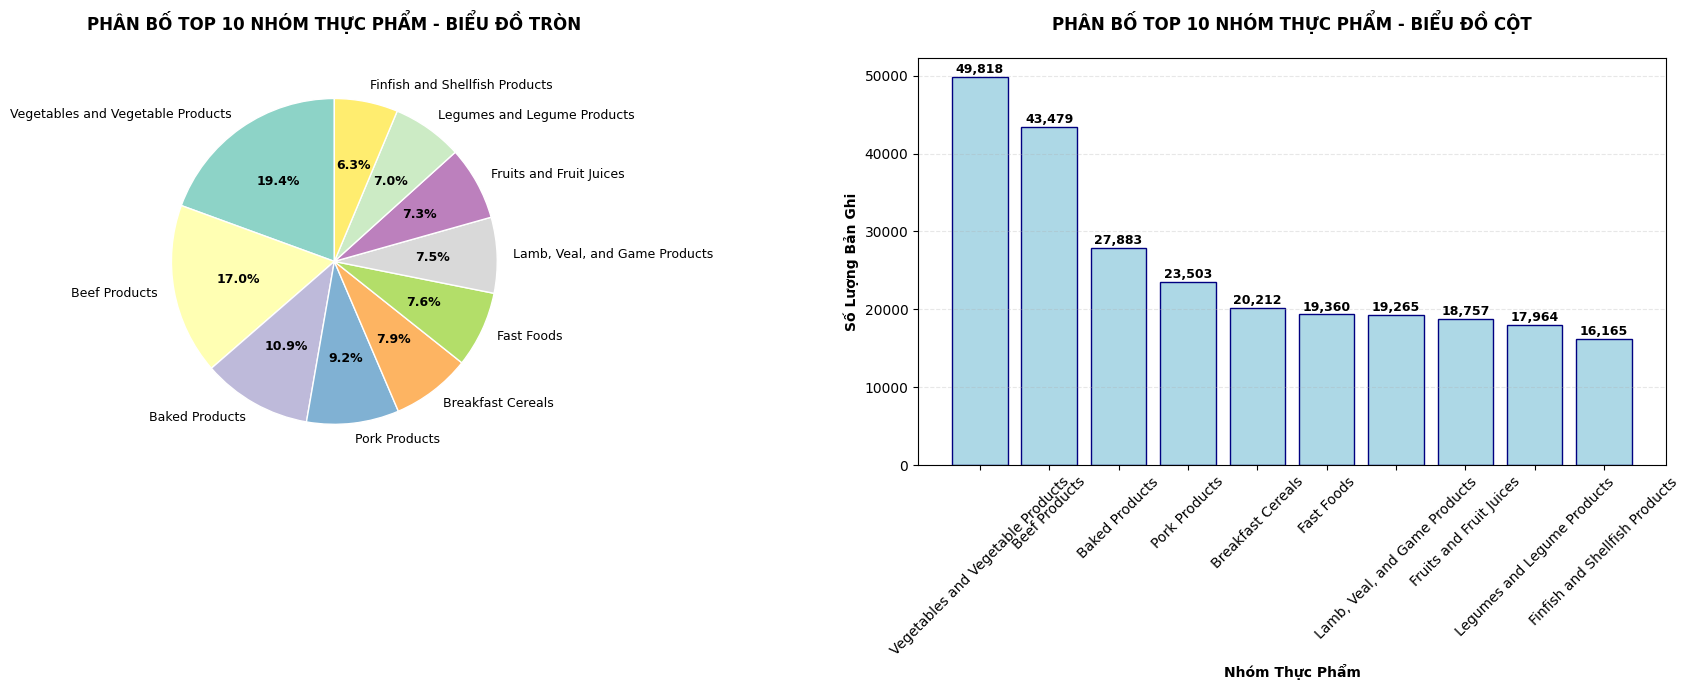

In [ ]:
fgroup_dist = ndata['fgroup'].value_counts().head(10)

# Tạo figure với 2 subplot cạnh nhau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# BIỂU ĐỒ TRÒN (trái)
colors = plt.cm.Set3(np.linspace(0, 1, len(fgroup_dist)))
wedges, texts, autotexts = ax1.pie(fgroup_dist.values,
                                  labels=fgroup_dist.index,
                                  autopct='%1.1f%%',
                                  colors=colors,
                                  startangle=90,
                                  textprops={'fontsize': 9},
                                  wedgeprops={'edgecolor': 'w', 'linewidth': 1})

ax1.set_title('PHÂN BỐ TOP 10 NHÓM THỰC PHẨM - BIỂU ĐỒ TRÒN', fontsize=12, fontweight='bold', pad=20)

# Tùy chỉnh phần trăm
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

# BIỂU ĐỒ CỘT (phải)
bars = ax2.bar(fgroup_dist.index, fgroup_dist.values, color='lightblue', edgecolor='navy')
ax2.set_title('PHÂN BỐ TOP 10 NHÓM THỰC PHẨM - BIỂU ĐỒ CỘT', fontsize=12, fontweight='bold', pad=20)
ax2.set_xlabel('Nhóm Thực Phẩm', fontweight='bold')
ax2.set_ylabel('Số Lượng Bản Ghi', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm số liệu lên các cột
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{height:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

**Nhóm chiếm ưu thế:**

- Rau củ & Sản phẩm từ rau dẫn đầu (19.4%) - phản ánh tính đa dạng và quan trọng của nhóm này

- Sản phẩm thịt bò (17.0%) - nhóm protein động vật phổ biến nhất

- Sản phẩm nướng (10.9%) - thực phẩm chế biến sẵn chiếm tỷ trọng đáng kể

**Câu hỏi 2: Nhóm chất dinh dưỡng nào chiếm tỷ lệ lớn trong cơ sở dữ liệu USDA?**

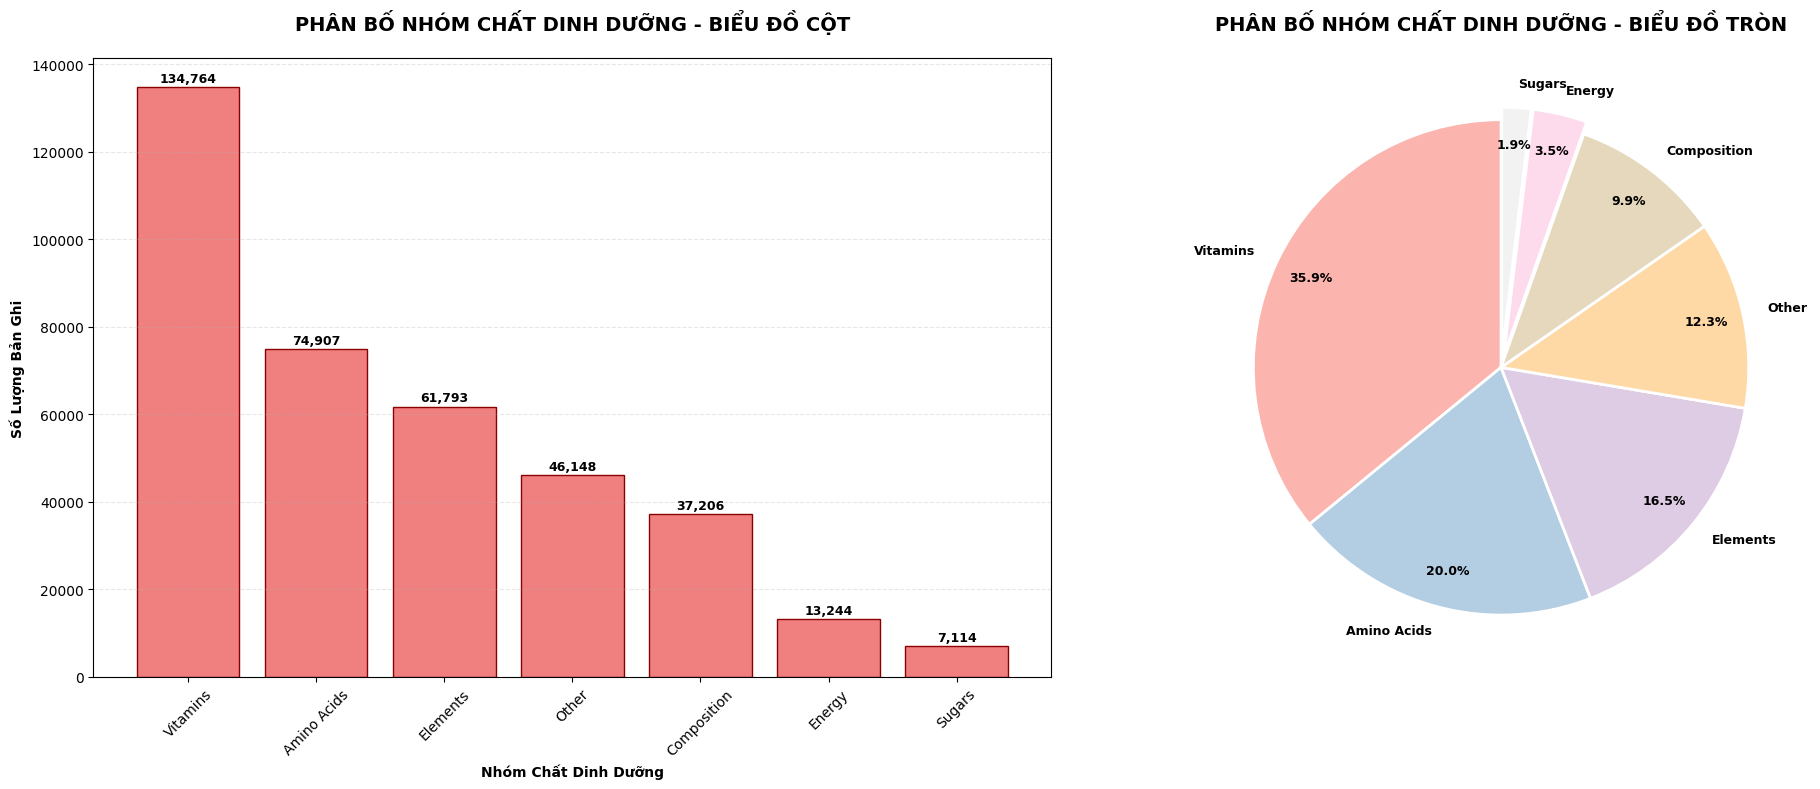

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

nutgroup_dist = ndata['nutgroup'].value_counts()

# Tạo figure với 2 subplot cạnh nhau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# BIỂU ĐỒ CỘT (trái)
bars = ax1.bar(nutgroup_dist.index, nutgroup_dist.values, color='lightcoral', edgecolor='darkred')
ax1.set_title('PHÂN BỐ NHÓM CHẤT DINH DƯỠNG - BIỂU ĐỒ CỘT', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Nhóm Chất Dinh Dưỡng', fontweight='bold')
ax1.set_ylabel('Số Lượng Bản Ghi', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm số liệu lên các cột
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{height:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# BIỂU ĐỒ TRÒN (phải) - Sửa lỗi chữ đè lên nhau
colors = plt.cm.Pastel1(np.linspace(0, 1, len(nutgroup_dist)))

# Tính toán khoảng cách cho các phần nhỏ để tránh đè chữ
explode = [0.05 if (count/np.sum(nutgroup_dist.values)) < 0.05 else 0 for count in nutgroup_dist.values]

wedges, texts, autotexts = ax2.pie(nutgroup_dist.values,
                                  labels=nutgroup_dist.index,
                                  autopct='%1.1f%%',
                                  colors=colors,
                                  startangle=90,
                                  explode=explode,  # Thêm khoảng cách cho phần nhỏ
                                  textprops={'fontsize': 9, 'fontweight': 'bold'},
                                  wedgeprops={'edgecolor': 'w', 'linewidth': 2},
                                  pctdistance=0.85)  # Đẩy phần trăm vào trong

ax2.set_title('PHÂN BỐ NHÓM CHẤT DINH DƯỠNG - BIỂU ĐỒ TRÒN', fontsize=14, fontweight='bold', pad=20)

# Tùy chỉnh phần trăm trong biểu đồ tròn
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# Điều chỉnh vị trí các nhãn để tránh đè lên nhau
for text in texts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()

**Nhóm chiếm ưu thế:**
- Vitamins dẫn đầu rõ rệt (35.9%) - Cho thấy cơ sở dữ liệu USDA rất chi tiết về vi chất dinh dưỡng,

- Amino Acids (20.0%) - Quan tâm đến chất lượng protein

- Elements (16.5%) - Khoáng chất đa lượng và vi lượng

- Other (12.3%) - Các hợp chất đặc biệt khác

**Câu hỏi 1:Trung bình năng lượng (kcal) của từng nhóm thực phẩm là bao nhiêu?**

In [ ]:
ndata[ndata['nutrient']=="Energy"].groupby('fgroup')['value'].mean()

,value
fgroup,
Baby Foods,426.389952
Baked Products,931.931452
Beef Products,559.323625
Beverages,303.875899
Breakfast Cereals,824.916873
Cereal Grains and Pasta,739.040984
Dairy and Egg Products,514.355140
Ethnic Foods,541.821212
Fast Foods,647.979452


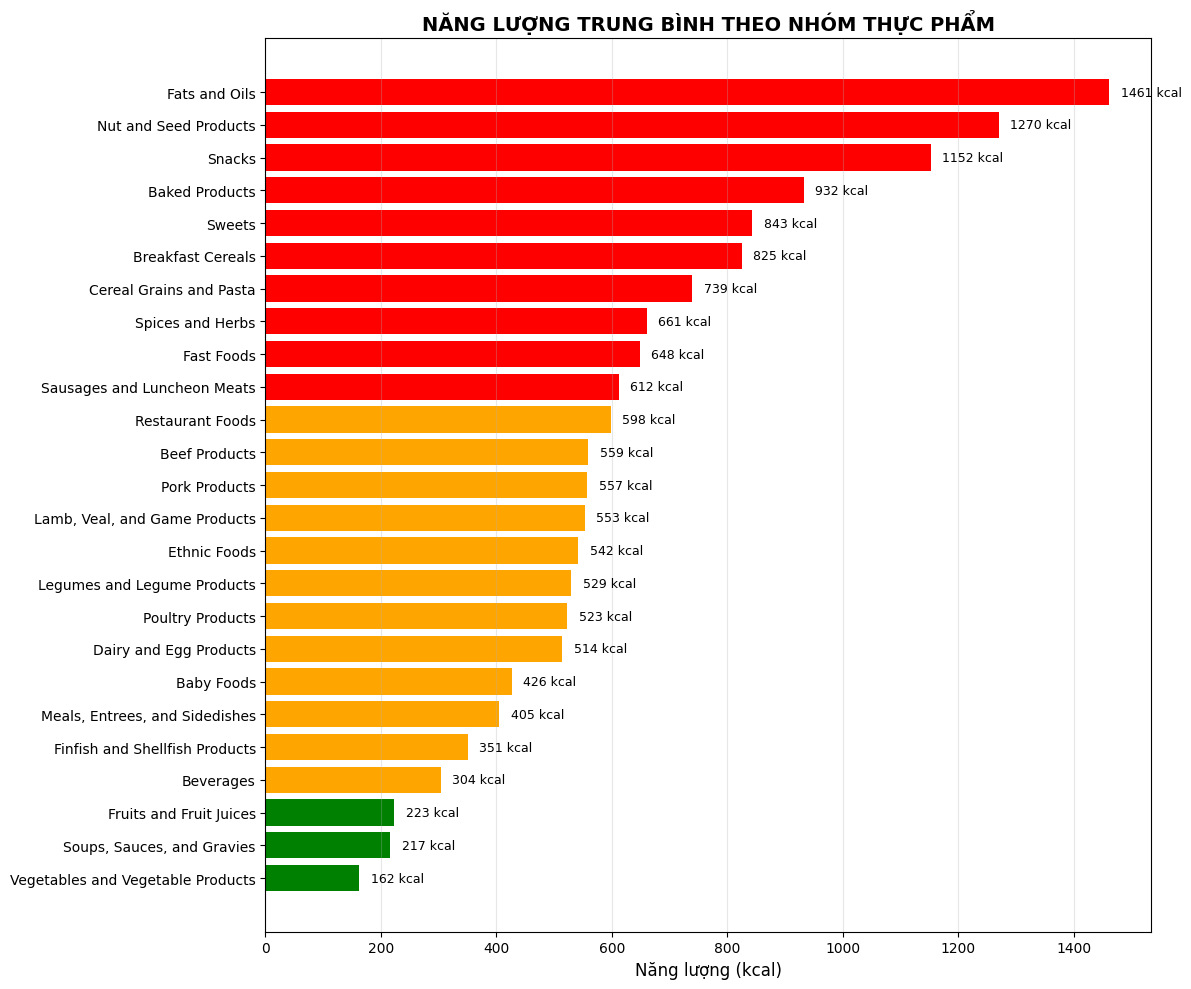

In [ ]:
energy_data = ndata[ndata['nutrient']=="Energy"].groupby('fgroup')['value'].mean()
energy_sorted = energy_data.sort_values(ascending=True)

# Vẽ biểu đồ
plt.figure(figsize=(12, 10))
bars = plt.barh(energy_sorted.index, energy_sorted.values,
                color=['red' if x >= 600 else 'orange' if x >= 300 else 'green' for x in energy_sorted.values])

# Tùy chỉnh giao diện
plt.xlabel('Năng lượng (kcal)', fontsize=12)
plt.title('NĂNG LƯỢNG TRUNG BÌNH THEO NHÓM THỰC PHẨM', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Thêm giá trị trên mỗi cột
for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2,
             f'{width:.0f} kcal', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

- **ĐỐI VỚI NGƯỜI GIẢM CÂN NÊN LỰA CHỌN CÁC NHÓM THỰC PHẨM <300 kcal**

- **ĐỐI VỚI NGƯỜI MUỐN DUY TRÌ CÂN NẶNG NÊN LỰA CHỌN CÁC NHÓM THỰC PHẨM TỪ 300-600 kcal**
- **ĐỐI VỚI NGƯỜI MUỐN TĂNG CÂN NÊN LỰA CHỌN CÁC NHÓM THỰC PHẨM ≥600 kcal**

**Lưu ý: Đây chỉ là khuyến nghị dựa trên năng lượng, cần kết hợp với các chỉ số dinh dưỡng khác như đường, chất béo, chất xơ!**


**Loại thực phẩm nào chứa protein cao nhất trong nhóm “Dairy and Egg Products”?**

In [ ]:
dairy_protein = ndata[(ndata['fgroup'] == "Dairy and Egg Products") &
                      (ndata['nutrient'] == "Protein")]

# Tìm thực phẩm có protein cao nhất
max_protein_food = dairy_protein.loc[dairy_protein['value'].idxmax()]
print("🏆 THỰC PHẨM GIÀU PROTEIN NHẤT TRONG NHÓM SỮA & TRỨNG")
print("=" * 60)
print(f"Tên thực phẩm: {max_protein_food['food']}")
print(f"Hàm lượng protein: {max_protein_food['value']} g")
print(f"ID: {max_protein_food['id']}")

🏆 THỰC PHẨM GIÀU PROTEIN NHẤT TRONG NHÓM SỮA & TRỨNG
Tên thực phẩm: Cheese, parmesan, low sodium
Hàm lượng protein: 41.6 g
ID: 43340


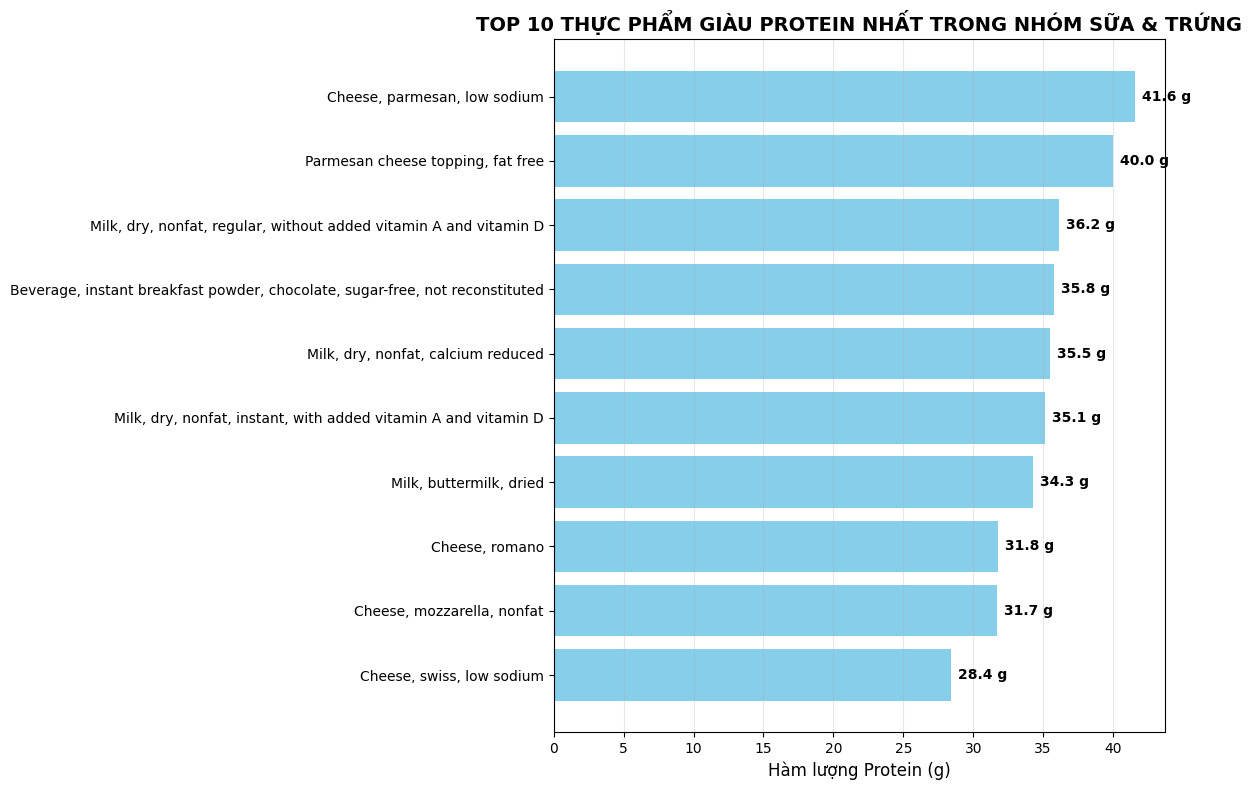

In [ ]:
top_10 = dairy_protein.nlargest(10, 'value')

plt.figure(figsize=(12, 8))
bars = plt.barh(top_10['food'], top_10['value'], color='skyblue')

# Tùy chỉnh biểu đồ
plt.xlabel('Hàm lượng Protein (g)', fontsize=12)
plt.title('TOP 10 THỰC PHẨM GIÀU PROTEIN NHẤT TRONG NHÓM SỮA & TRỨNG',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Đảo ngược để cao nhất ở trên

# Thêm giá trị trên các cột
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f} g', ha='left', va='center', fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**TOP 10 này giúp ta:**

✅ Ra quyết định thông minh khi mua thực phẩm

✅ Tối ưu hóa chế độ ăn theo mục tiêu cá nhân

✅ Tiết kiệm chi phí bằng cách chọn thực phẩm hiệu quả nhất

**Nhóm nào có độ đa dạng dinh dưỡng cao nhất (nhiều loại chất khác nhau)?**

In [ ]:
# Tính độ đa dạng dinh dưỡng cho tất cả nhóm
diversity_data = ndata.groupby('fgroup')['nutrient'].nunique().sort_values(ascending=False)

print("📊 DANH SÁCH ĐỘ ĐA DẠNG DINH DƯỠNG CỦA TẤT CẢ NHÓM THỰC PHẨM")
print("=" * 80)

# In tất cả các nhóm
for i, (nhom, so_chat) in enumerate(diversity_data.items(), 1):
    print(f"{i:2d}. {nhom:<45} {so_chat:>3} chất dinh dưỡng")

# Tìm nhóm đa dạng nhất và ít đa dạng nhất
nhom_da_dang_nhat = diversity_data.index[0]
so_chat_da_dang_nhat = diversity_data.iloc[0]
nhom_it_da_dang_nhat = diversity_data.index[-1]
so_chat_it_da_dang_nhat = diversity_data.iloc[-1]

print(f"\n🎯 NHÓM ĐA DẠNG DINH DƯỠNG NHẤT: {nhom_da_dang_nhat}")
print(f"📈 Số lượng chất dinh dưỡng: {so_chat_da_dang_nhat}")

print(f"\n📉 NHÓM ÍT ĐA DẠNG DINH DƯỠNG NHẤT: {nhom_it_da_dang_nhat}")
print(f"📊 Số lượng chất dinh dưỡng: {so_chat_it_da_dang_nhat}")

📊 DANH SÁCH ĐỘ ĐA DẠNG DINH DƯỠNG CỦA TẤT CẢ NHÓM THỰC PHẨM
 1. Vegetables and Vegetable Products              94 chất dinh dưỡng
 2. Sweets                                         93 chất dinh dưỡng
 3. Dairy and Egg Products                         93 chất dinh dưỡng
 4. Snacks                                         92 chất dinh dưỡng
 5. Fats and Oils                                  92 chất dinh dưỡng
 6. Baked Products                                 91 chất dinh dưỡng
 7. Legumes and Legume Products                    91 chất dinh dưỡng
 8. Fruits and Fruit Juices                        91 chất dinh dưỡng
 9. Nut and Seed Products                          91 chất dinh dưỡng
10. Ethnic Foods                                   90 chất dinh dưỡng
11. Restaurant Foods                               90 chất dinh dưỡng
12. Sausages and Luncheon Meats                    89 chất dinh dưỡng
13. Poultry Products                               89 chất dinh dưỡng
14. Beverages                 

In [ ]:
# Phân tích chi tiết nhóm đa dạng nhất
nhom_da_dang_nhat = diversity_data.index[0]

print(f"🔍 PHÂN TÍCH CHI TIẾT: {nhom_da_dang_nhat}")
print("=" * 60)

# Liệt kê tất cả chất dinh dưỡng trong nhóm này
cac_chat_dinh_duong = ndata[ndata['fgroup'] == nhom_da_dang_nhat]['nutrient'].unique()

print(f"📋 DANH SÁCH {len(cac_chat_dinh_duong)} CHẤT DINH DƯỠNG:")
for i, chat in enumerate(sorted(cac_chat_dinh_duong), 1):
    print(f"  {i:2d}. {chat}")

# Phân loại chất dinh dưỡng theo nhóm
print(f"\n🎯 PHÂN LOẠI CHẤT DINH DƯỠNG TRONG {nhom_da_dang_nhat}:")
cac_nhom_chat = ndata[ndata['fgroup'] == nhom_da_dang_nhat]['nutgroup'].unique()
for nhom_chat in sorted(cac_nhom_chat):
    so_chat_trong_nhom = ndata[(ndata['fgroup'] == nhom_da_dang_nhat) &
                              (ndata['nutgroup'] == nhom_chat)]['nutrient'].nunique()
    print(f"  • {nhom_chat}: {so_chat_trong_nhom} chất")

🔍 PHÂN TÍCH CHI TIẾT: Vegetables and Vegetable Products
📋 DANH SÁCH 94 CHẤT DINH DƯỠNG:
   1. Adjusted Protein
   2. Alanine
   3. Alcohol, ethyl
   4. Arginine
   5. Ash
   6. Aspartic acid
   7. Beta-sitosterol
   8. Betaine
   9. Caffeine
  10. Calcium, Ca
  11. Campesterol
  12. Carbohydrate, by difference
  13. Carotene, alpha
  14. Carotene, beta
  15. Cholesterol
  16. Choline, total
  17. Copper, Cu
  18. Cryptoxanthin, beta
  19. Cystine
  20. Dihydrophylloquinone
  21. Energy
  22. Fatty acids, total monounsaturated
  23. Fatty acids, total polyunsaturated
  24. Fatty acids, total saturated
  25. Fatty acids, total trans
  26. Fatty acids, total trans-monoenoic
  27. Fatty acids, total trans-polyenoic
  28. Fiber, total dietary
  29. Fluoride, F
  30. Folate, DFE
  31. Folate, food
  32. Folate, total
  33. Folic acid
  34. Fructose
  35. Galactose
  36. Glucose (dextrose)
  37. Glutamic acid
  38. Glycine
  39. Histidine
  40. Hydroxyproline
  41. Iron, Fe
  42. Isoleucine
 

##**4.2. Phân Tích Đa Biến (Multivariate Analysis)**

**Câu hỏi 1: Nhóm thực phẩm nào có hàm lượng kẽm cao nhất và thấp nhất? Sự chênh lệch này lớn tới mức nào?**

In [ ]:
result = ndata.groupby(["nutrient", "fgroup"])["value"].quantile(0.5)

<BarContainer object of 25 artists>

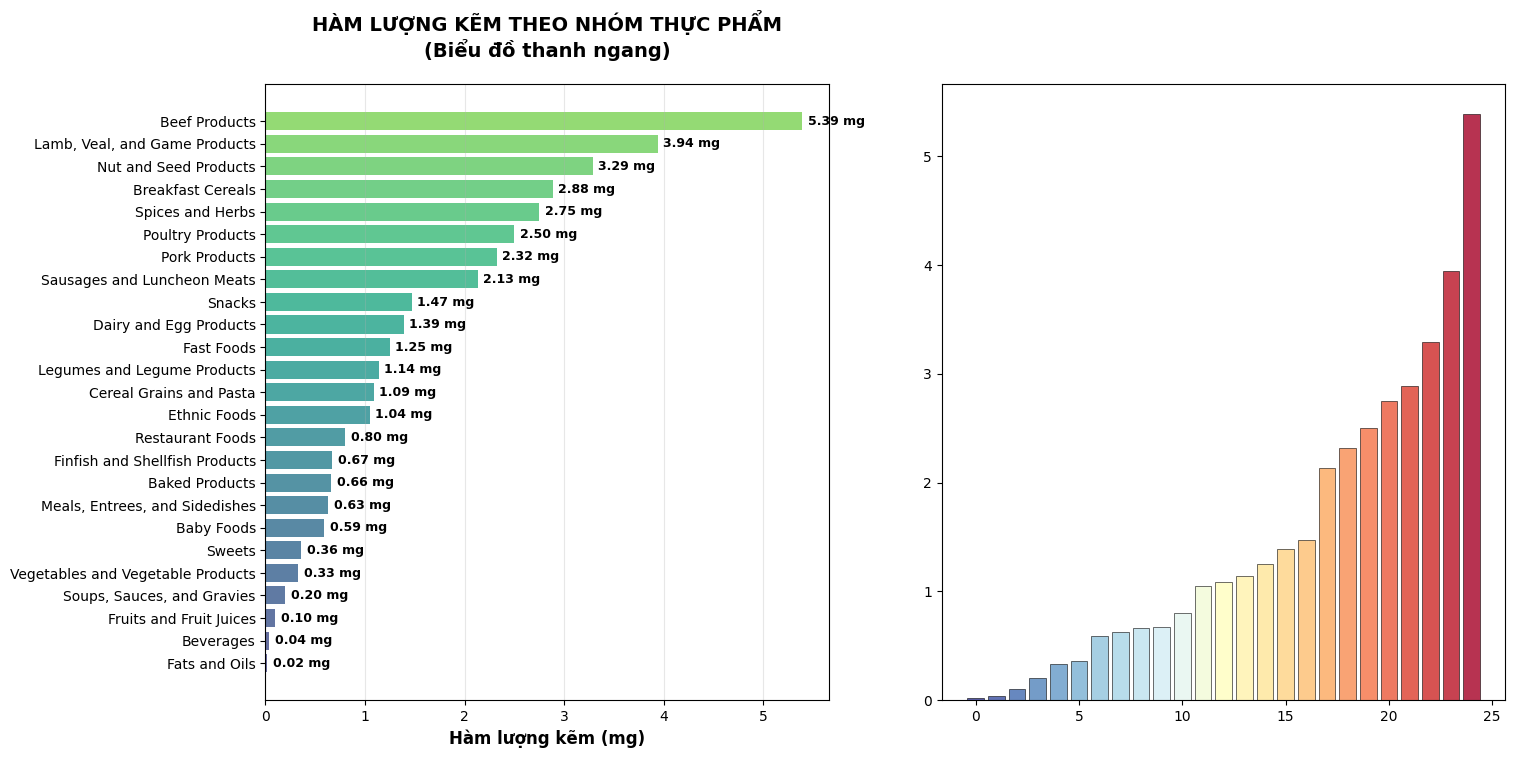

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Lấy dữ liệu kẽm
zinc_data = result["Zinc, Zn"].sort_values(ascending=True)  # Sắp xếp tăng dần để biểu đồ ngang dễ nhìn

# Tạo figure với 2 biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# BIỂU ĐỒ 1: BAR CHART NGANG
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(zinc_data)))
bars = ax1.barh(range(len(zinc_data)), zinc_data.values, color=colors, alpha=0.8)

# Thêm giá trị trên các cột
for i, (bar, value) in enumerate(zip(bars, zinc_data.values)):
    ax1.text(value + max(zinc_data.values)*0.01, i, f'{value:.2f} mg',
             va='center', fontweight='bold', fontsize=9)

ax1.set_yticks(range(len(zinc_data)))
ax1.set_yticklabels(zinc_data.index, fontsize=10)
ax1.set_xlabel('Hàm lượng kẽm (mg)', fontweight='bold', fontsize=12)
ax1.set_title('HÀM LƯỢNG KẼM THEO NHÓM THỰC PHẨM\n(Biểu đồ thanh ngang)',
              fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3)

# BIỂU ĐỒ 2: BAR CHART DỌC CÓ MÀU PHÂN CẤP
ax2.bar(range(len(zinc_data)), zinc_data.values,
        color=plt.cm.RdYlBu_r(np.linspace(0, 1, len(zinc_data))),
        alpha=0.8, edgecolor='black', linewidth=0.5)

**Từ biểu đồ hàm lượng kẽm, ta có khuyến nghị cụ thể:**

- **CHO NGƯỜI THIẾU KẼM**

  - Beef Products (5.39mg) - Thịt bò các loại

  - Lamb, Veal (3.94mg) - Thịt cừu, thịt bê

  - Nut and Seed Products (3.29mg) - Các loại hạt

  - Breakfast Cereals (2.88mg) - Ngũ cốc ăn sáng

  - Poultry Products (2.50mg) - Thịt gia cầm

**Câu hỏi 2: Dựa trên dữ liệu này, người ăn chay trường họ có thể bổ sung kẽm từ những nguồn thực vật nào có hàm lượng cao nhất trong biểu đồ?**

- **NGUỒN KẼM THAY THẾ CHO NGƯỜI ĂN CHAY**

  - Nut and Seed Products (3.29mg) - HẠT CÁC LOẠI

  - Breakfast Cereals (2.88mg) - NGŨ CỐC NGUYÊN HẠT

  - Legumes (1.14mg) - ĐẬU CÁC LOẠI



bảng thực phẩm có hàm lượng amino acid cao nhất

In [ ]:
by_nutrient = ndata.groupby(["nutgroup", "nutrient"])
def get_maximum(x):
 return x.loc[x.value.idxmax()]
max_foods = by_nutrient.apply(get_maximum)[["value", "food"]]
# make the food a little smaller
max_foods["food"] = max_foods["food"].str[:50]

/tmp/ipython-input-1417839404.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_foods = by_nutrient.apply(get_maximum)[["value", "food"]]


In [ ]:
max_foods.loc["Amino Acids"]["food"]

,food
nutrient,
Alanine,"Gelatins, dry powder, unsweetened"
Arginine,"Seeds, sesame flour, low-fat"
Aspartic acid,Soy protein isolate
Cystine,"Seeds, cottonseed flour, low fat (glandless)"
Glutamic acid,Soy protein isolate
Glycine,"Gelatins, dry powder, unsweetened"
Histidine,"Whale, beluga, meat, dried (Alaska Native)"
Hydroxyproline,"KENTUCKY FRIED CHICKEN, Fried Chicken, ORIGINA..."
Isoleucine,"Soy protein isolate, PROTEIN TECHNOLOGIES INTE..."


##**4.2.1.Phân tích so sánh**

**Câu hỏi 1: So sánh hàm lượng protein và lipid (chất béo) giữa nhóm “Meat” và “Dairy”?**

In [ ]:
print("Danh sách các nhóm thực phẩm trong dữ liệu:")
print(ndata['fgroup'].unique())

Danh sách các nhóm thực phẩm trong dữ liệu:
['Dairy and Egg Products' 'Spices and Herbs' 'Baby Foods' 'Fats and Oils'
 'Poultry Products' 'Soups, Sauces, and Gravies'
 'Sausages and Luncheon Meats' 'Breakfast Cereals'
 'Fruits and Fruit Juices' 'Pork Products'
 'Vegetables and Vegetable Products' 'Nut and Seed Products'
 'Beef Products' 'Beverages' 'Finfish and Shellfish Products'
 'Legumes and Legume Products' 'Lamb, Veal, and Game Products'
 'Baked Products' 'Snacks' 'Sweets' 'Cereal Grains and Pasta' 'Fast Foods'
 'Meals, Entrees, and Sidedishes' 'Ethnic Foods' 'Restaurant Foods']


In [ ]:
# Các nhóm thuộc về thịt
nhom_thit = [
    'Beef Products',              # Sản phẩm Thịt Bò
    'Pork Products',              # Sản phẩm Thịt Heo
    'Poultry Products',           # Sản phẩm Gia cầm
    'Lamb, Veal, and Game Products',  # Thịt Cừu, Bê và Thú rừng
    'Sausages and Luncheon Meats',    # Xúc xích và Thịt nguội
    'Finfish and Shellfish Products'  # Cá và Hải sản
]

print("🥩 NHÓM THỊT VÀ THỰC PHẨM ĐỘNG VẬT:")
print("=" * 50)
for i, nhom in enumerate(nhom_thit, 1):
    print(f"{i}. {nhom}")

🥩 NHÓM THỊT VÀ THỰC PHẨM ĐỘNG VẬT:
1. Beef Products
2. Pork Products
3. Poultry Products
4. Lamb, Veal, and Game Products
5. Sausages and Luncheon Meats
6. Finfish and Shellfish Products


In [ ]:
# Các nhóm thuộc về sữa và trứng
nhom_sua = [
    'Dairy and Egg Products'      # Sản phẩm Sữa và Trứng
]

print("\n🥛 NHÓM SỮA VÀ TRỨNG:")
print("=" * 40)
for i, nhom in enumerate(nhom_sua, 1):
    print(f"{i}. {nhom}")


🥛 NHÓM SỮA VÀ TRỨNG:
1. Dairy and Egg Products


In [ ]:
# So sánh tổng hợp nhóm THỊT vs nhóm SỮA
print("📊 SO SÁNH TOÀN DIỆN: NHÓM THỊT vs NHÓM SỮA")
print("=" * 60)

# Tính trung bình protein và lipid cho mỗi nhóm lớn
def tinh_trung_binh_nhom(danh_sach_nhom, chat_dinh_duong):
    values = []
    for nhom in danh_sach_nhom:
        chat_data = ndata[(ndata['fgroup'] == nhom) & (ndata['nutrient'] == chat_dinh_duong)]['value']
        if not chat_data.empty:
            values.extend(chat_data.tolist())
    return sum(values) / len(values) if values else 0

# Tính toán
protein_thit = tinh_trung_binh_nhom(nhom_thit, 'Protein')
lipid_thit = tinh_trung_binh_nhom(nhom_thit, 'Total lipid (fat)')

protein_sua = tinh_trung_binh_nhom(nhom_sua, 'Protein')
lipid_sua = tinh_trung_binh_nhom(nhom_sua, 'Total lipid (fat)')

print(f"🥩 NHÓM THỊT ({len(nhom_thit)} nhóm con):")
print(f"  • Protein trung bình: {protein_thit:.2f} g")
print(f"  • Lipid trung bình: {lipid_thit:.2f} g")
print(f"  • Tỷ lệ P/L: {protein_thit/lipid_thit:.2f}")

print(f"\n🥛 NHÓM SỮA ({len(nhom_sua)} nhóm con):")
print(f"  • Protein trung bình: {protein_sua:.2f} g")
print(f"  • Lipid trung bình: {lipid_sua:.2f} g")
print(f"  • Tỷ lệ P/L: {protein_sua/lipid_sua:.2f}")

print(f"\n🔍 KẾT LUẬN:")
print(f"• Protein cao hơn: {'THỊT' if protein_thit > protein_sua else 'SỮA'}")
print(f"• Lipid cao hơn: {'THỊT' if lipid_thit > lipid_sua else 'SỮA'}")

📊 SO SÁNH TOÀN DIỆN: NHÓM THỊT vs NHÓM SỮA
🥩 NHÓM THỊT (6 nhóm con):
  • Protein trung bình: 22.69 g
  • Lipid trung bình: 11.73 g
  • Tỷ lệ P/L: 1.93

🥛 NHÓM SỮA (1 nhóm con):
  • Protein trung bình: 14.22 g
  • Lipid trung bình: 10.32 g
  • Tỷ lệ P/L: 1.38

🔍 KẾT LUẬN:
• Protein cao hơn: THỊT
• Lipid cao hơn: THỊT


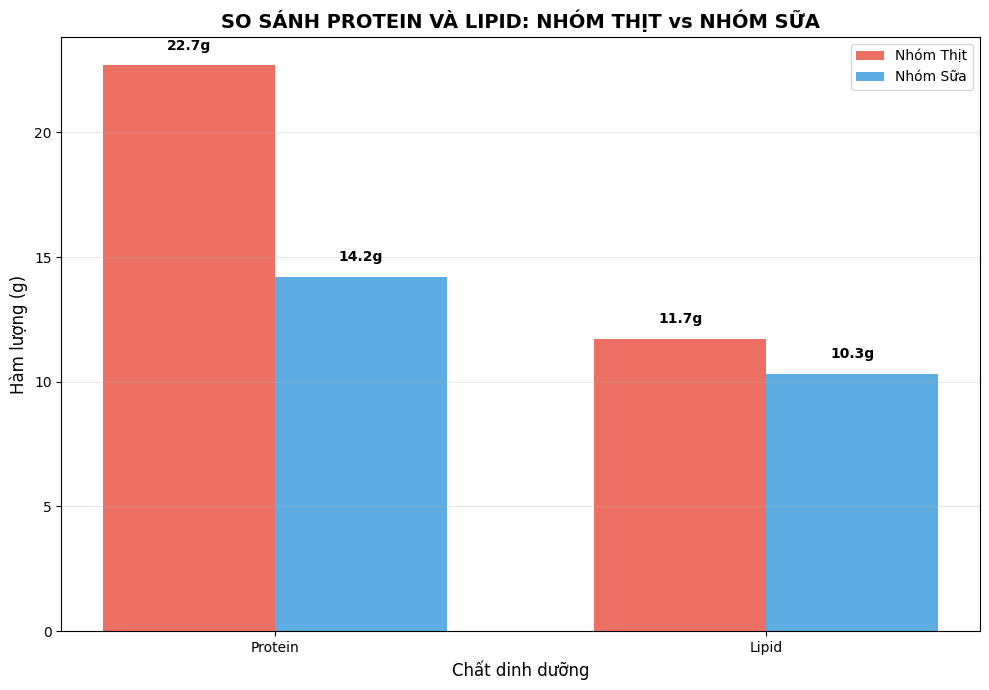

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Chuẩn bị dữ liệu cho biểu đồ
categories = ['Protein', 'Lipid']
thit_values = [protein_thit, lipid_thit]
sua_values = [protein_sua, lipid_sua]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 7))

bars1 = ax.bar(x - width/2, thit_values, width, label='Nhóm Thịt', color='#E74C3C', alpha=0.8)
bars2 = ax.bar(x + width/2, sua_values, width, label='Nhóm Sữa', color='#3498DB', alpha=0.8)

ax.set_xlabel('Chất dinh dưỡng', fontsize=12)
ax.set_ylabel('Hàm lượng (g)', fontsize=12)
ax.set_title('SO SÁNH PROTEIN VÀ LIPID: NHÓM THỊT vs NHÓM SỮA', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Thêm giá trị trên các cột
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}g', ha='center', va='bottom', fontweight='bold')

add_labels(bars1)
add_labels(bars2)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**ĐÁNH GIÁ**

- **PROTEIN:**

  - Nhóm Thịt: 22.7g

  - Nhóm Sữa: 14.2g

==> Thịt cao hơn Sữa: 8.5g (chênh lệch đáng kể)

- **LIPID (Chất béo):**

  - Nhóm Thịt: 11.7g

  - Nhóm Sữa: 10.3g

==> Thịt cao hơn Sữa: 1.4g (chênh lệch nhỏ)

**KHUYẾN NGHỊ SỬ DỤNG:**

- **ƯU TIÊN NHÓM THỊT KHI:**

  -  Tập gym, xây dựng cơ bắp (nhu cầu protein cao)

  -  Giảm cân cần no lâu (protein giúp no lâu hơn)

  -  Hồi phục sau tập luyện

- **ƯU TIÊN NHÓM SỮA KHI:**

  - Cần canxi cho xương (sữa giàu canxi hơn)

  - Trẻ em đang phát triển (cân bằng dinh dưỡng)

  - Bữa ăn nhẹ, dễ tiêu hóa

In [ ]:
# Phân tích chi tiết từng nhóm con trong nhóm thịt
print("\n📈 PHÂN TÍCH CHI TIẾT TỪNG LOẠI THỊT:")
print("=" * 50)

for nhom in nhom_thit:
    protein = ndata[(ndata['fgroup'] == nhom) & (ndata['nutrient'] == 'Protein')]['value'].mean()
    lipid = ndata[(ndata['fgroup'] == nhom) & (ndata['nutrient'] == 'Total lipid (fat)')]['value'].mean()
    print(f"• {nhom}:")
    print(f"  Protein: {protein:.1f}g | Lipid: {lipid:.1f}g | P/L: {protein/lipid:.2f}")


📈 PHÂN TÍCH CHI TIẾT TỪNG LOẠI THỊT:
• Beef Products:
  Protein: 24.8g | Lipid: 12.3g | P/L: 2.01
• Pork Products:
  Protein: 21.9g | Lipid: 13.5g | P/L: 1.62
• Poultry Products:
  Protein: 23.5g | Lipid: 11.0g | P/L: 2.14
• Lamb, Veal, and Game Products:
  Protein: 23.4g | Lipid: 12.5g | P/L: 1.87
• Sausages and Luncheon Meats:
  Protein: 15.9g | Lipid: 17.5g | P/L: 0.90
• Finfish and Shellfish Products:
  Protein: 20.3g | Lipid: 4.8g | P/L: 4.22


In [ ]:
# Lọc dữ liệu cho 2 nhóm và 2 chất dinh dưỡng
nhom_so_sanh = ["Cereal Grains and Pasta", "Vegetables and Vegetable Products"]
chatt_so_sanh = ["Energy", "Protein"]

data_so_sanh = ndata[
    (ndata['fgroup'].isin(nhom_so_sanh)) &
    (ndata['nutrient'].isin(chatt_so_sanh))
]

# Tạo pivot table
pivot_result = data_so_sanh.pivot_table(
    values='value',
    index='fgroup',
    columns='nutrient',
    aggfunc='mean'
).round(2)

print("📊 DỮ LIỆU NĂNG LƯỢNG VÀ PROTEIN")
print("=" * 55)
print(pivot_result)

# Tính tỷ lệ Energy-to-Protein
pivot_result['Energy_to_Protein_Ratio'] = pivot_result['Energy'] / pivot_result['Protein']

print(f"\n🎯 TỶ LỆ ENERGY-TO-PROTEIN")
print("=" * 40)
for nhom in nhom_so_sanh:
    ratio = pivot_result.loc[nhom, 'Energy_to_Protein_Ratio']
    print(f"• {nhom}: {ratio:.2f} kcal/g protein")

📊 DỮ LIỆU NĂNG LƯỢNG VÀ PROTEIN
nutrient                           Energy  Protein
fgroup                                            
Cereal Grains and Pasta            739.04     9.11
Vegetables and Vegetable Products  162.05     2.82

🎯 TỶ LỆ ENERGY-TO-PROTEIN
• Cereal Grains and Pasta: 81.12 kcal/g protein
• Vegetables and Vegetable Products: 57.46 kcal/g protein


In [ ]:
# Tính toán chi tiết
print("🥖🥬 SO SÁNH TỶ LỆ ENERGY-PROTEIN: NGŨ CỐC vs RAU CỦ")
print("=" * 65)

# Tính tỷ lệ cho từng nhóm
ty_le_grains = pivot_result.loc['Cereal Grains and Pasta', 'Energy'] / pivot_result.loc['Cereal Grains and Pasta', 'Protein']
ty_le_vegetables = pivot_result.loc['Vegetables and Vegetable Products', 'Energy'] / pivot_result.loc['Vegetables and Vegetable Products', 'Protein']

print(f"\n📈 KẾT QUẢ:")
print(f"• Ngũ cốc & Mì ống: {ty_le_grains:.1f} kcal/g protein")
print(f"• Rau & Sản phẩm từ rau: {ty_le_vegetables:.1f} kcal/g protein")

print(f"\n🔍 PHÂN TÍCH:")
print(f"• Chênh lệch: {abs(ty_le_grains - ty_le_vegetables):.1f} kcal/g protein")
print(f"• Ngũ cốc cần {ty_le_grains/ty_le_vegetables:.1f} lần năng lượng hơn để có cùng lượng protein")

print(f"\n💡 Ý NGHĨA:")
if ty_le_grains > ty_le_vegetables:
    print("→ RAU CỦ hiệu quả hơn về mặt năng lượng-protein (ít calo hơn cho cùng lượng protein)")
else:
    print("→ NGŨ CỐC hiệu quả hơn về mặt năng lượng-protein")

🥖🥬 SO SÁNH TỶ LỆ ENERGY-PROTEIN: NGŨ CỐC vs RAU CỦ

📈 KẾT QUẢ:
• Ngũ cốc & Mì ống: 81.1 kcal/g protein
• Rau & Sản phẩm từ rau: 57.5 kcal/g protein

🔍 PHÂN TÍCH:
• Chênh lệch: 23.7 kcal/g protein
• Ngũ cốc cần 1.4 lần năng lượng hơn để có cùng lượng protein

💡 Ý NGHĨA:
→ RAU CỦ hiệu quả hơn về mặt năng lượng-protein (ít calo hơn cho cùng lượng protein)


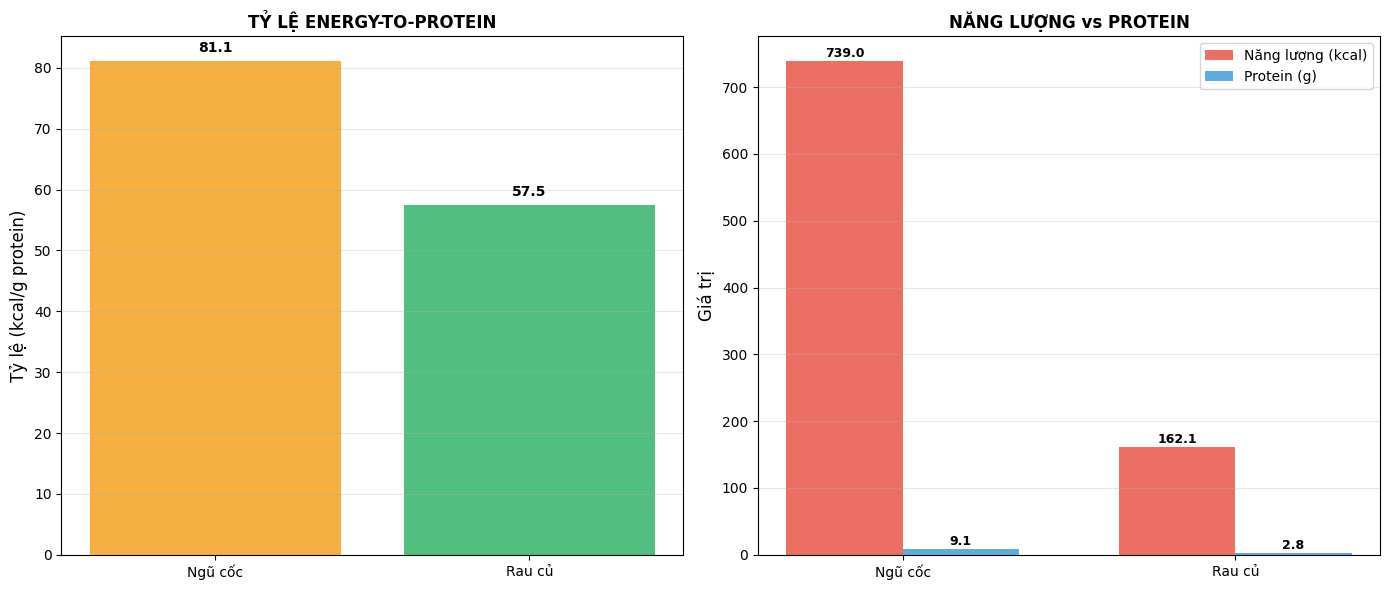

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Chuẩn bị dữ liệu cho biểu đồ
nhom = ['Ngũ cốc', 'Rau củ']
ty_le = [ty_le_grains, ty_le_vegetables]
nang_luong = [pivot_result.loc['Cereal Grains and Pasta', 'Energy'],
              pivot_result.loc['Vegetables and Vegetable Products', 'Energy']]
protein = [pivot_result.loc['Cereal Grains and Pasta', 'Protein'],
           pivot_result.loc['Vegetables and Vegetable Products', 'Protein']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ 1: Tỷ lệ Energy-to-Protein
bars1 = ax1.bar(nhom, ty_le, color=['#F39C12', '#27AE60'], alpha=0.8)
ax1.set_ylabel('Tỷ lệ (kcal/g protein)', fontsize=12)
ax1.set_title('TỶ LỆ ENERGY-TO-PROTEIN', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Thêm giá trị trên biểu đồ 1
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# Biểu đồ 2: So sánh trực tiếp Energy và Protein
x = np.arange(len(nhom))
width = 0.35

bars2 = ax2.bar(x - width/2, nang_luong, width, label='Năng lượng (kcal)', color='#E74C3C', alpha=0.8)
bars3 = ax2.bar(x + width/2, protein, width, label='Protein (g)', color='#3498DB', alpha=0.8)

ax2.set_ylabel('Giá trị', fontsize=12)
ax2.set_title('NĂNG LƯỢNG vs PROTEIN', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(nhom)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Thêm giá trị trên biểu đồ 2
for bars in [bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

***TÍNH TOÁN TỶ LỆ:***

  - Ngũ cốc: 739 ÷ 9.1 = 81.2 kcal/g protein

  - Rau củ: 162.1 ÷ 2.8 = 57.9 kcal/g protein

*739 kcal là trung bình của TẤT CẢ các loại thực phẩm trong nhóm "Cereal Grains and Pasta"*

*9.1 g là trung bình của TẤT CẢ các loại thực phẩm trong nhóm "Cereal Grains and Pasta"*

***Ý NGHĨA THỰC TẾ:***

**Bạn phải tiêu thụ bao nhiêu calo để có 1g protein?**

   - **Với NGŨ CỐC:**

      - Cần 81.2 kcal để có 1g protein

Hiệu quả THẤP ==> Phải ăn nhiều calo mới có đủ protein

  - **Với RAU CỦ:**

      - Chỉ cần 57.9 kcal để có 1g protein

Hiệu quả CAO ==> Chỉ cần ít calo đã có lượng protein tương đương

***ỨNG DỤNG THỰC TẾ:***

- **Ngũ cốc phù hợp khi:**

  - Tăng cân, tăng cơ

  - Vận động viên cần nhiều năng lượng

  - Hoạt động thể lực cao

- **Rau củ phù hợp khi:**

  - Giảm cân (nhiều protein, ít calo)

  - Kiểm soát đường huyết

  - Ăn kiêng ít calo

##**4.2.2.Phân tích tương quan**

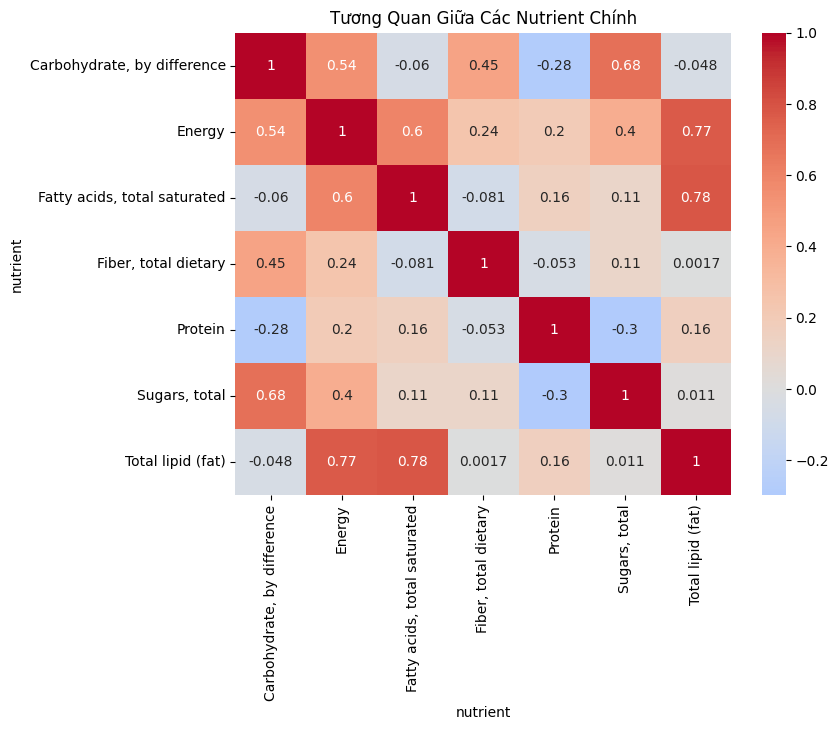

In [ ]:
key_nutrients = ['Energy', 'Total lipid (fat)', 'Carbohydrate, by difference', 'Protein', 'Sugars, total', 'Fatty acids, total saturated', 'Fiber, total dietary']
key_data = ndata[ndata['nutrient'].isin(key_nutrients)]
pivot_corr = key_data.pivot_table(values='value', index='id', columns='nutrient').corr()
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Tương Quan Giữa Các Nutrient Chính')
plt.show()

**Chỉ số tương quan giữa "Total lipid (fat)" và "Energy" là 0.77.**

- **Tại sao lại như vậy?**
  - Về mặt dinh dưỡng, điều này là hoàn to hợp lý vì chất béo là nguồn cung cấp năng lượng đậm đặc nhất. Cụ thể:

    - 1g Chất béo cung cấp 9 kcal.

    - Trong khi đó, 1g Carbohydrate hoặc 1g Protein chỉ cung cấp 4 kcal.

   - Vì vậy, khi một thực phẩm có hàm lượng chất béo (Total lipid) cao, nó chắc chắn sẽ có hàm lượng năng lượng (Energy) cao, và con số 0.77 trong bảng đã xác nhận mối quan hệ chặt chẽ này

**Chỉ số tương quan giữa 'Fatty acids, total saturated' và 'Total lipid (fat)'  là 0.78.**

**Giải thích:**

- Giá trị 0.78 cho thấy một mối tương quan thuận rất chặt chẽ. Điều này có nghĩa là:

  - Khi hàm lượng Tổng chất béo (Total lipid) trong một loại thực phẩm tăng lên, thì hàm lượng Chất béo bão hòa (Fatty acids, total saturated) trong thực phẩm đó cũng có xu hướng tăng theo.

  - Và ngược lại, thực phẩm ít chất béo nói chung thì cũng thường ít chất béo bão hòa.

**Chỉ số tương quan giữa  'Carbohydrate, by difference' và 'Sugars, total' là 0.68.**

**Giải thích từ góc độ dinh dưỡng:**

- Mối tương quan "khá mạnh" (0.68) thay vì "rất mạnh" (trên 0.8) cho thấy:

  - Có những thực phẩm carbohydrate cao chủ yếu là tinh bột (như cơm, bánh mì, mì ít đường) thì có thể có hàm lượng đường không cao.

  - Có những thực phẩm carbohydrate cao chủ yếu là đường (như kẹo, nước ngọt, trái cây sấy) nên làm cho mối tương quan này trở nên chặt chẽ hơn.



**Nhóm thực phẩm nào có năng lượng cao nhưng protein thấp (chất “rỗng”)?**

In [ ]:
# Tính trung bình năng lượng và protein cho từng nhóm
group_stats = ndata[ndata['nutrient'].isin(['Energy', 'Protein'])].pivot_table(
    values='value',
    index='fgroup',
    columns='nutrient',
    aggfunc='mean'
).dropna()

# Tính tỷ lệ Energy/Protein
group_stats['Energy_Protein_Ratio'] = group_stats['Energy'] / group_stats['Protein']
group_stats['Chất_rỗng_score'] = (group_stats['Energy'] / group_stats['Energy'].mean()) / (group_stats['Protein'] / group_stats['Protein'].mean())

# Sắp xếp theo độ "rỗng" (tỷ lệ Energy/Protein cao)
group_stats_sorted = group_stats.sort_values('Energy_Protein_Ratio', ascending=False)

print("🏆 XẾP HẠNG NHÓM THỰC PHẨM THEO ĐỘ 'RỖNG':")
print("=" * 80)
print(f"{'Nhóm':<40} {'Energy':>8} {'Protein':>8} {'Tỷ lệ E/P':>10} {'Score':>8}")
print("-" * 80)

for i, (group, row) in enumerate(group_stats_sorted.iterrows(), 1):
    print(f"{i:2d}. {group:<38} {row['Energy']:>7.1f} {row['Protein']:>7.1f} {row['Energy_Protein_Ratio']:>9.1f} {row['Chất_rỗng_score']:>7.1f}")

🏆 XẾP HẠNG NHÓM THỰC PHẨM THEO ĐỘ 'RỖNG':
Nhóm                                       Energy  Protein  Tỷ lệ E/P    Score
--------------------------------------------------------------------------------
 1. Fats and Oils                           1461.0     0.8    1788.4    32.6
 2. Fruits and Fruit Juices                  222.7     0.9     256.5     4.7
 3. Beverages                                303.9     1.3     227.3     4.1
 4. Sweets                                   843.1     4.3     194.2     3.5
 5. Baked Products                           931.9     6.7     138.4     2.5
 6. Snacks                                  1152.1     9.8     117.8     2.1
 7. Breakfast Cereals                        824.9     7.6     108.5     2.0
 8. Baby Foods                               426.4     4.2     100.9     1.8
 9. Nut and Seed Products                   1270.3    14.9      85.5     1.6
10. Cereal Grains and Pasta                  739.0     9.1      81.2     1.5
11. Soups, Sauces, and Gravi

In [ ]:
import pandas as pd
import numpy as np

def tim_thuc_pham_rong(ndata, top_n=20):
    """
    Tìm thực phẩm rỗng dựa trên tỷ lệ Energy/Protein cao
    """
    # Lấy dữ liệu Energy và Protein
    energy_protein_data = ndata[ndata['nutrient'].isin(['Energy', 'Protein'])]

    # Tạo pivot table
    pivot_data = energy_protein_data.pivot_table(
        values='value',
        index=['fgroup', 'food'],  # Nhóm và tên thực phẩm
        columns='nutrient',
        aggfunc='mean'
    ).dropna()

    # Tính tỷ lệ Energy/Protein
    pivot_data['Energy_Protein_Ratio'] = pivot_data['Energy'] / pivot_data['Protein']

    # Tính điểm "độ rỗng" (Energy cao, Protein thấp)
    pivot_data['Rong_Score'] = (pivot_data['Energy'] / pivot_data['Energy'].median()) / (pivot_data['Protein'] / pivot_data['Protein'].median())

    # Sắp xếp theo độ rỗng
    thuc_pham_rong = pivot_data.nlargest(top_n, 'Rong_Score')

    return thuc_pham_rong

# Chạy phân tích
thuc_pham_rong = tim_thuc_pham_rong(ndata, 25)

print("🚨 TOP THỰC PHẨM 'RỖNG' NHẤT (Năng lượng cao - Protein thấp)")
print("=" * 100)
print(f"{'STT':<4} {'Nhóm':<30} {'Thực phẩm':<50} {'Energy':>8} {'Protein':>8} {'Tỷ lệ':>10}")
print("-" * 100)

for i, ((fgroup, food), row) in enumerate(thuc_pham_rong.iterrows(), 1):
    print(f"{i:<4} {fgroup:<30} {food:<50} {row['Energy']:>7.1f} {row['Protein']:>7.1f} {row['Energy_Protein_Ratio']:>9.1f}")

🚨 TOP THỰC PHẨM 'RỖNG' NHẤT (Năng lượng cao - Protein thấp)
STT  Nhóm                           Thực phẩm                                            Energy  Protein      Tỷ lệ
----------------------------------------------------------------------------------------------------
1    Baby Foods                     Babyfood, apple-cranberry juice                      119.5     0.0       inf
2    Baby Foods                     Babyfood, juice, pear                                122.5     0.0       inf
3    Baby Foods                     Fluid replacement, electrolyte solution (include PEDIALYTE)    25.5     0.0       inf
4    Baked Products                 Leavening agents, baking powder, double-acting, sodium aluminum sulfate   137.5     0.0       inf
5    Baked Products                 Leavening agents, cream of tartar                    668.5     0.0       inf
6    Beverages                      Alcoholic beverage, creme de menthe, 72 proof        961.5     0.0       inf
7    Beverages 

In [ ]:
import pandas as pd
import numpy as np

# Tính trung bình năng lượng và protein cho từng nhóm
group_stats = ndata[ndata['nutrient'].isin(['Energy', 'Protein'])].pivot_table(
    values='value',
    index='fgroup',
    columns='nutrient',
    aggfunc='mean'
).dropna()

# Tính tỷ lệ Energy/Protein
group_stats['Energy_Protein_Ratio'] = group_stats['Energy'] / group_stats['Protein']

# Tính điểm "độ rỗng" - sử dụng median để tránh ảnh hưởng bởi outliers
energy_median = group_stats['Energy'].median()
protein_median = group_stats['Protein'].median()
group_stats['Rong_Score'] = (group_stats['Energy'] / energy_median) / (group_stats['Protein'] / protein_median)

# Sắp xếp theo độ "rỗng" (tỷ lệ Energy/Protein cao)
group_stats_sorted = group_stats.sort_values('Rong_Score', ascending=False)

print("🏆 XẾP HẠNG NHÓM THỰC PHẨM THEO ĐỘ 'RỖNG'")
print("=" * 90)
print(f"{'STT':<3} {'Nhóm':<35} {'Energy':>8} {'Protein':>8} {'Tỷ lệ E/P':>12} {'Score':>10}")
print("-" * 90)

for i, (group, row) in enumerate(group_stats_sorted.iterrows(), 1):
    print(f"{i:<3} {group:<35} {row['Energy']:>7.1f} {row['Protein']:>7.1f} {row['Energy_Protein_Ratio']:>11.1f} {row['Rong_Score']:>9.1f}")


🏆 XẾP HẠNG NHÓM THỰC PHẨM THEO ĐỘ 'RỖNG'
STT Nhóm                                  Energy  Protein    Tỷ lệ E/P      Score
------------------------------------------------------------------------------------------
1   Fats and Oils                        1461.0     0.8      1788.4      36.3
2   Fruits and Fruit Juices               222.7     0.9       256.5       5.2
3   Beverages                             303.9     1.3       227.3       4.6
4   Sweets                                843.1     4.3       194.2       3.9
5   Baked Products                        931.9     6.7       138.4       2.8
6   Snacks                               1152.1     9.8       117.8       2.4
7   Breakfast Cereals                     824.9     7.6       108.5       2.2
8   Baby Foods                            426.4     4.2       100.9       2.0
9   Nut and Seed Products                1270.3    14.9        85.5       1.7
10  Cereal Grains and Pasta               739.0     9.1        81.2       1.6
11  So

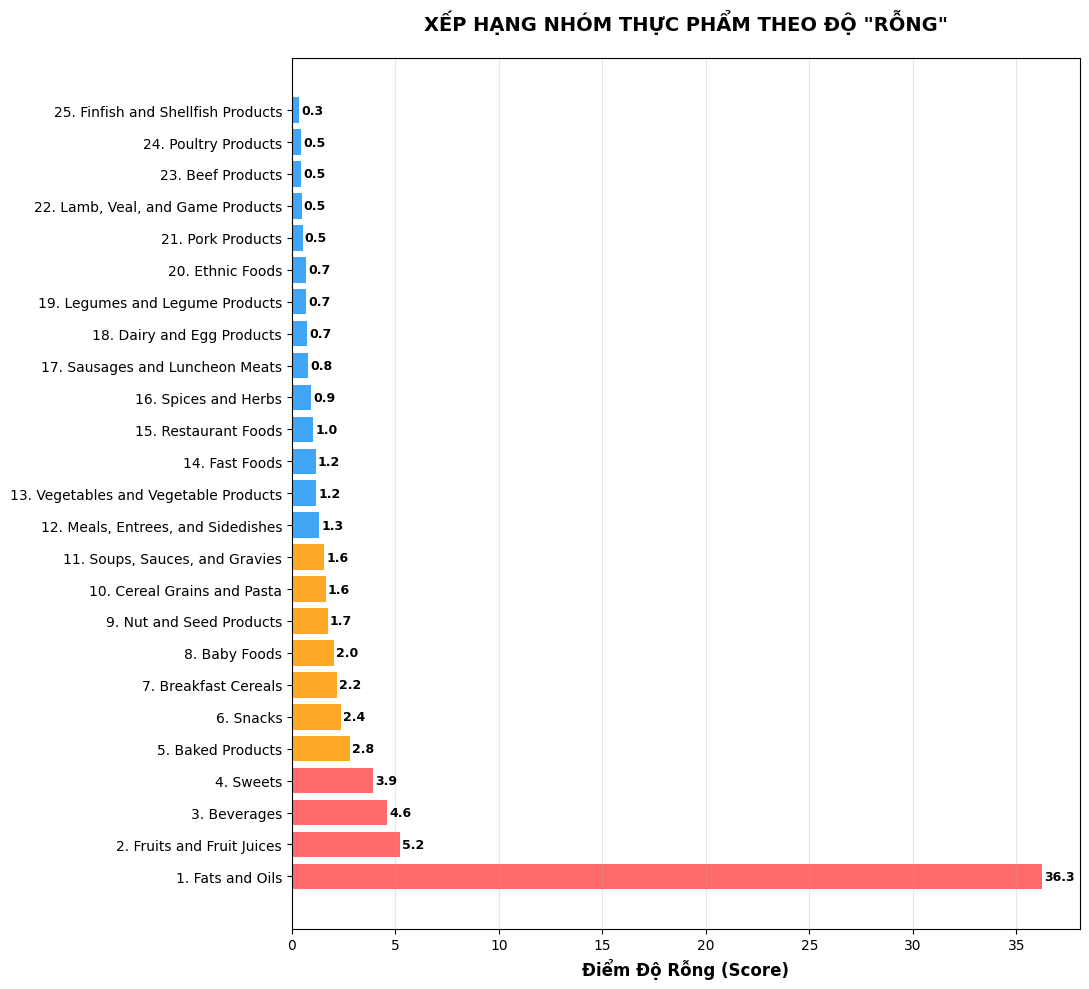

In [ ]:


# Thiết lập style
plt.style.use('default')
sns.set_palette("husl")

# BIỂU ĐỒ 1: Biểu đồ cột cho Score độ rỗng (Ngang)
plt.figure(figsize=(11, 10))
bars = plt.barh(range(len(group_stats_sorted)), group_stats_sorted['Rong_Score'],
                color=['#ff6b6b' if score > 3 else '#ffa726' if score > 1.5 else '#42a5f5' for score in group_stats_sorted['Rong_Score']])
plt.yticks(range(len(group_stats_sorted)), [f"{i+1}. {group}" for i, group in enumerate(group_stats_sorted.index)], fontsize=10)
plt.xlabel('Điểm Độ Rỗng (Score)', fontsize=12, fontweight='bold')
plt.title('XẾP HẠNG NHÓM THỰC PHẨM THEO ĐỘ "RỖNG"', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)

# Thêm giá trị trên mỗi cột
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.1f}',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

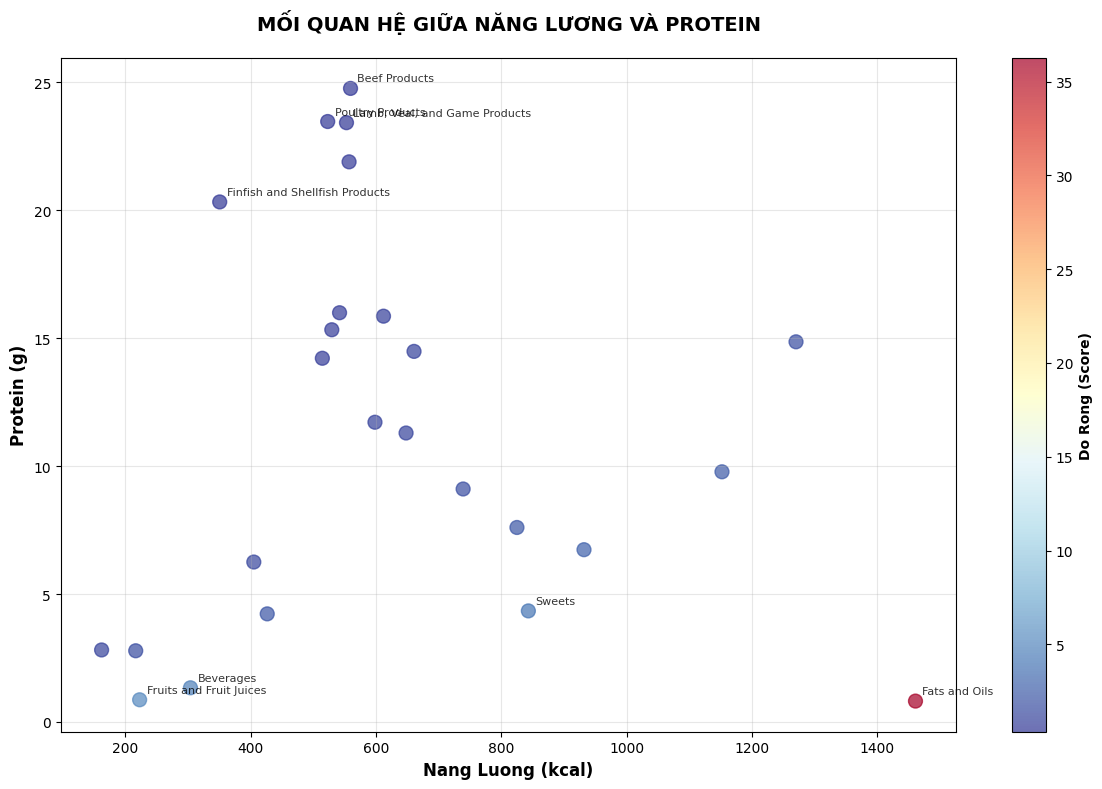

In [ ]:
# BIỂU ĐỒ 3: Scatter plot Energy vs Protein
plt.figure(figsize=(12, 8))
scatter = plt.scatter(group_stats_sorted['Energy'], group_stats_sorted['Protein'],
                     c=group_stats_sorted['Rong_Score'], cmap='RdYlBu_r', s=100, alpha=0.7)
plt.xlabel('Nang Luong (kcal)', fontsize=12, fontweight='bold')
plt.ylabel('Protein (g)', fontsize=12, fontweight='bold')
plt.title('MỐI QUAN HỆ GIỮA NĂNG LƯƠNG VÀ PROTEIN', fontsize=14, fontweight='bold', pad=20)
plt.grid(alpha=0.3)

# Thêm chú thích cho các điểm quan trọng
for i, (group, row) in enumerate(group_stats_sorted.iterrows()):
    if row['Rong_Score'] > 3 or row['Rong_Score'] < 0.5:
        plt.annotate(group, (row['Energy'], row['Protein']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

# Thêm colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Do Rong (Score)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Số lượng thực phẩm có đủ dữ liệu Water và Energy: 6632
📊 HỆ SỐ TƯƠNG QUAN GIỮA WATER VÀ ENERGY: -0.912


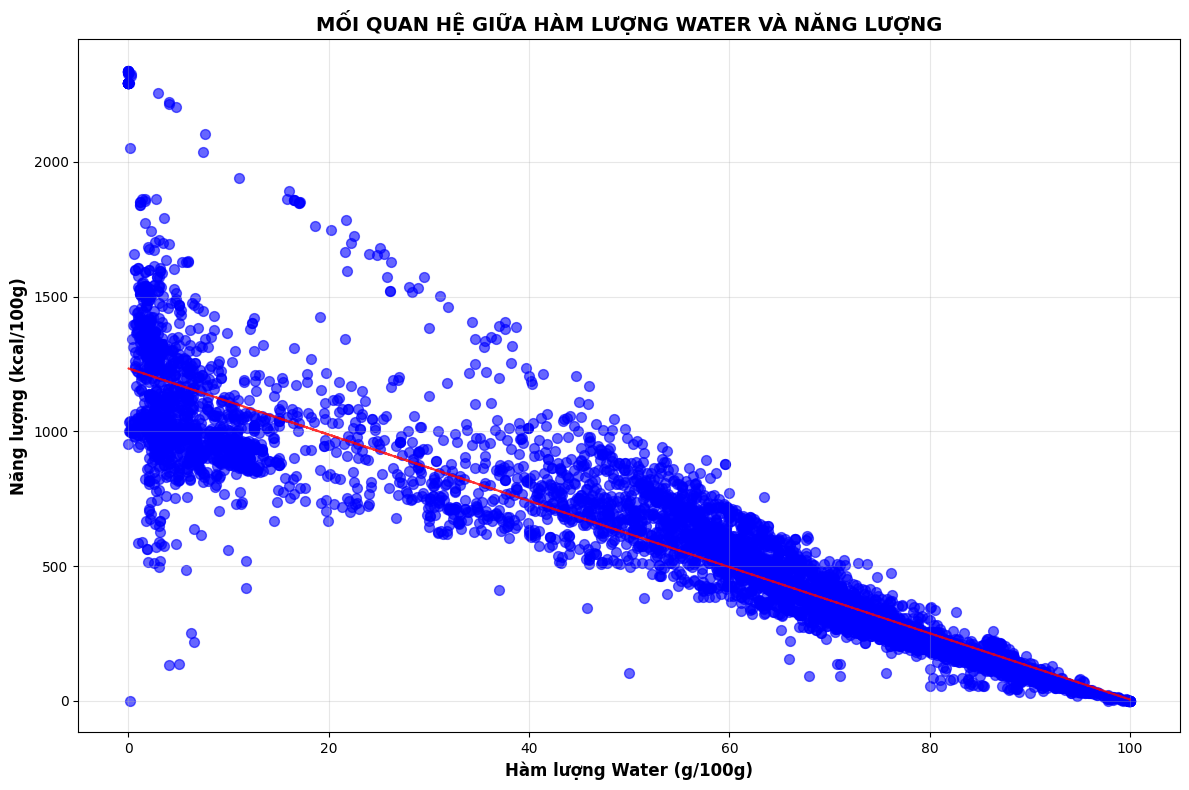


📈 PHÂN TÍCH THEO NHÓM THỰC PHẨM:
Nhóm                                 Water (g) Energy (kcal)  Tỷ lệ W/E
----------------------------------------------------------------------
Baby Foods                               65.9       426.4       0.2
Baked Products                           21.5       931.9       0.0
Beef Products                            62.0       559.3       0.1
Beverages                                71.7       303.9       0.2
Breakfast Cereals                        18.4       824.9       0.0
Cereal Grains and Pasta                  29.1       739.0       0.0
Dairy and Egg Products                   60.5       514.4       0.1
Ethnic Foods                             59.9       541.8       0.1
Fast Foods                               50.9       648.0       0.1
Fats and Oils                            29.5      1461.0       0.0
Finfish and Shellfish Products           71.6       350.5       0.2
Fruits and Fruit Juices                  76.6       222.7       0.3
Lamb, V

/tmp/ipython-input-2200164957.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  water_summary = pivot_water_energy.groupby('Water_Category')['Energy'].agg(['mean', 'median', 'count'])


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Lấy dữ liệu Water và Energy
water_energy_data = ndata[ndata['nutrient'].isin(['Water', 'Energy'])]

# Tạo pivot table
pivot_water_energy = water_energy_data.pivot_table(
    values='value',
    index=['fgroup', 'food'],
    columns='nutrient',
    aggfunc='mean'
).dropna()

print(f"Số lượng thực phẩm có đủ dữ liệu Water và Energy: {len(pivot_water_energy)}")

# Phân tích tương quan
correlation = pivot_water_energy['Water'].corr(pivot_water_energy['Energy'])
print(f"📊 HỆ SỐ TƯƠNG QUAN GIỮA WATER VÀ ENERGY: {correlation:.3f}")

# Vẽ biểu đồ scatter
plt.figure(figsize=(12, 8))
plt.scatter(pivot_water_energy['Water'], pivot_water_energy['Energy'],
           alpha=0.6, s=50, color='blue')
plt.xlabel('Hàm lượng Water (g/100g)', fontsize=12, fontweight='bold')
plt.ylabel('Năng lượng (kcal/100g)', fontsize=12, fontweight='bold')
plt.title('MỐI QUAN HỆ GIỮA HÀM LƯỢNG WATER VÀ NĂNG LƯỢNG', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Thêm đường hồi quy
z = np.polyfit(pivot_water_energy['Water'], pivot_water_energy['Energy'], 1)
p = np.poly1d(z)
plt.plot(pivot_water_energy['Water'], p(pivot_water_energy['Water']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

# Phân tích theo nhóm thực phẩm
print("\n📈 PHÂN TÍCH THEO NHÓM THỰC PHẨM:")
print("=" * 60)

# Tính trung bình Water và Energy theo nhóm
group_water_energy = water_energy_data.pivot_table(
    values='value',
    index='fgroup',
    columns='nutrient',
    aggfunc='mean'
).dropna()

# Tính tương quan theo nhóm
print(f"{'Nhóm':<35} {'Water (g)':>10} {'Energy (kcal)':>12} {'Tỷ lệ W/E':>10}")
print("-" * 70)

for group, row in group_water_energy.iterrows():
    water_energy_ratio = row['Water'] / row['Energy'] if row['Energy'] > 0 else 0
    print(f"{group:<35} {row['Water']:>9.1f} {row['Energy']:>11.1f} {water_energy_ratio:>9.1f}")

# Phân loại thực phẩm theo hàm lượng Water
pivot_water_energy['Water_Category'] = pd.cut(pivot_water_energy['Water'],
                                            bins=[0, 50, 80, 100],
                                            labels=['Khô (<50g)', 'Trung bình (50-80g)', 'Ướt (>80g)'])

print("\n💧 SO SÁNH NĂNG LƯỢNG THEO HÀM LƯỢNG WATER:")
water_summary = pivot_water_energy.groupby('Water_Category')['Energy'].agg(['mean', 'median', 'count'])
print(water_summary)

##**4.2.3.Phân tích dự đoán**

In [ ]:
import pandas as pd
import numpy as np

# Lấy dữ liệu các chất dinh dưỡng quan trọng
essential_nutrients = ['Energy', 'Protein', 'Total lipid (fat)', 'Carbohydrate, by difference', 'Fiber, total dietary']
nutrient_data = ndata[ndata['nutrient'].isin(essential_nutrients)]

# Tạo pivot table cho các nhóm
group_nutrition = nutrient_data.pivot_table(
    values='value',
    index='fgroup',
    columns='nutrient',
    aggfunc='mean'
).dropna()

# Tính toán các chỉ số cân bằng
print("XÂY DỰNG BỘ CHỈ SỐ DINH DƯỠNG CÂN BẰNG")
print("=" * 80)

# 1. Tính tỷ lệ phần trăm macro
total_macro = group_nutrition['Protein'] + group_nutrition['Total lipid (fat)'] + group_nutrition['Carbohydrate, by difference']
group_nutrition['Protein_Percent'] = (group_nutrition['Protein'] / total_macro) * 100
group_nutrition['Fat_Percent'] = (group_nutrition['Total lipid (fat)'] / total_macro) * 100
group_nutrition['Carb_Percent'] = (group_nutrition['Carbohydrate, by difference'] / total_macro) * 100

# 2. Chỉ số cân bằng đa chất (Macro Balance Index)
ideal_protein = 25
ideal_fat = 25
ideal_carb = 50

group_nutrition['Macro_Balance_Score'] = 1 - (
    abs(group_nutrition['Protein_Percent'] - ideal_protein) +
    abs(group_nutrition['Fat_Percent'] - ideal_fat) +
    abs(group_nutrition['Carb_Percent'] - ideal_carb)
) / 100

# 3. Chỉ số chất lượng protein (Protein Quality Index)
group_nutrition['Protein_Quality_Index'] = group_nutrition['Protein'] / group_nutrition['Energy'] * 100

# 4. Chỉ số chất xơ (Fiber Density Index)
group_nutrition['Fiber_Density_Index'] = group_nutrition['Fiber, total dietary'] / group_nutrition['Energy'] * 100

# 5. Chỉ số dinh dưỡng tổng thể (Overall Nutrition Score)
group_nutrition['Overall_Nutrition_Score'] = (
    group_nutrition['Macro_Balance_Score'] * 0.4 +
    (group_nutrition['Protein_Quality_Index'] / group_nutrition['Protein_Quality_Index'].max()) * 0.3 +
    (group_nutrition['Fiber_Density_Index'] / group_nutrition['Fiber_Density_Index'].max()) * 0.3
)

# Tạo DataFrame để hiển thị đẹp
display_df = group_nutrition.copy()
display_df = display_df.sort_values('Overall_Nutrition_Score', ascending=False)

# Đổi tên cột cho đẹp
display_df = display_df.rename(columns={
    'Protein_Percent': 'Protein(%)',
    'Fat_Percent': 'Fat(%)',
    'Carb_Percent': 'Carb(%)',
    'Fiber, total dietary': 'Fiber',
    'Macro_Balance_Score': 'Macro_Score',
    'Protein_Quality_Index': 'Protein_Quality',
    'Fiber_Density_Index': 'Fiber_Density',
    'Overall_Nutrition_Score': 'Overall_Score'
})

# Chọn các cột cần hiển thị
final_columns = ['Protein(%)', 'Fat(%)', 'Carb(%)', 'Fiber', 'Energy',
                 'Macro_Score', 'Protein_Quality', 'Fiber_Density', 'Overall_Score']

display_df = display_df[final_columns]

# Định dạng bảng với Styler
styled_df = display_df.style.format({
    'Protein(%)': '{:.1f}%',
    'Fat(%)': '{:.1f}%',
    'Carb(%)': '{:.1f}%',
    'Fiber': '{:.1f}',
    'Energy': '{:.1f}',
    'Macro_Score': '{:.2f}',
    'Protein_Quality': '{:.2f}',
    'Fiber_Density': '{:.3f}',
    'Overall_Score': '{:.2f}'
}).background_gradient(subset=['Overall_Score'], cmap='RdYlGn')\
  .background_gradient(subset=['Macro_Score'], cmap='YlOrBr')\
  .background_gradient(subset=['Protein_Quality'], cmap='Blues')\
  .background_gradient(subset=['Fiber_Density'], cmap='Greens')\
  .set_properties(**{
      'text-align': 'center',
      'font-size': '11px'
  }).set_table_styles([
      {'selector': 'th', 'props': [('background-color', '#2E86AB'),
                                   ('color', 'white'),
                                   ('font-weight', 'bold'),
                                   ('text-align', 'center')]},
      {'selector': 'caption', 'props': [('font-size', '14px'),
                                        ('font-weight', 'bold'),
                                        ('color', '#2E86AB')]}
  ]).set_caption('BỘ CHỈ SỐ DINH DƯỠNG CÂN BẰNG CHO TỪNG NHÓM THỰC PHẨM')

# Hiển thị bảng
print("\nBẢNG CHỈ SỐ DINH DƯỠNG CÂN BẰNG")
print("=" * 100)
styled_df

XÂY DỰNG BỘ CHỈ SỐ DINH DƯỠNG CÂN BẰNG

BẢNG CHỈ SỐ DINH DƯỠNG CÂN BẰNG


nutrient,Protein(%),Fat(%),Carb(%),Fiber,Energy,Macro_Score,Protein_Quality,Fiber_Density,Overall_Score
fgroup,,,,,,,,,
Legumes and Legume Products,35.2%,18.0%,46.8%,6.1,529.4,0.80,2.90,1.152,0.66
Vegetables and Vegetable Products,17.5%,5.8%,76.7%,3.0,162.1,0.47,1.74,1.829,0.58
Spices and Herbs,31.2%,36.8%,32.0%,6.8,660.7,0.64,2.19,1.030,0.54
Restaurant Foods,27.0%,26.2%,46.8%,2.0,598.3,0.94,1.96,0.326,0.53
Ethnic Foods,41.7%,29.0%,29.3%,4.2,541.8,0.59,2.95,0.770,0.51
Fast Foods,24.0%,27.2%,48.8%,1.4,648.0,0.96,1.74,0.216,0.51
"Meals, Entrees, and Sidedishes",18.7%,13.6%,67.7%,2.0,405.0,0.65,1.54,0.505,0.42
Dairy and Egg Products,38.8%,28.1%,33.1%,0.1,514.4,0.66,2.76,0.017,0.41
Nut and Seed Products,18.0%,46.3%,35.7%,8.7,1270.3,0.57,1.17,0.685,0.40


**Hỗ trợ Khuyến Nghị Dinh Dưỡng Cá Nhân**

**Cho người muốn ăn uống LÀNH MẠNH, CÂN ĐỐI nhất:**

- **Nhóm dẫn đầu:** Legumes and Legume Products (Đậu & Sản phẩm từ đậu) có Overall Score cao nhất (0.66). Điều này cho thấy đây là nhóm thực phẩm lý tưởng với tỷ lệ protein cao (35.2%), chất xơ cao (6.1%), và điểm chất lượng protein (Protein Quality = 2.90) rất tốt.

- **Khuyến nghị:** Khuyến khích các cá nhân ưu tiên nhóm đậu, đỗ, lentil trong bữa ăn để có được sự cân bằng dinh dưỡng tối ưu.

**Cho người ăn CHAY hoặc ăn THUẦN THỰC VẬT:**

- Nguồn protein thay thế hoàn hảo: Ngoài nhóm Legumes, có thể kết hợp với Vegetables (Rau củ, Overall Score 0.58) và Nut and Seed Products (Hạt, Overall Score 0.40). Lưu ý nhóm hạt có hàm lượng Fat và Energy rất cao, nên cần kiểm soát khẩu phần.

- **Cảnh báo:** Nhóm Dairy and Egg Products (Sữa & Trứng) có điểm chất lượng protein cao (2.76) nhưng điểm chất xơ gần như bằng 0 (0.017). Điều này nhấn mạnh việc người ăn chay cần bổ sung chất xơ từ rau, củ, quả nếu sử dụng sữa/trứng.

**Cho người tập luyện TĂNG CƠ:**

- **Ưu tiên protein chất lượng cao:** Các nhóm Finfish and Shellfish (Cá & Hải sản), Poultry Products (Thịt gia cầm), Beef Products (Thịt bò) có chỉ số Protein Quality rất cao (5.80, 4.49, 4.43) và tỷ lệ % protein cực kỳ cao (>65%).

- **Khuyến nghị:** Đây là nguồn protein lý tưởng để phục hồi và xây dựng cơ bắp. Tuy nhiên, cần lưu ý:

  - Chúng hầu như không có chất xơ.

  - Tỷ lệ Fat trong thịt gia cầm và đặc biệt là thịt bò, heo cũng khá cao.

- **Giải pháp:** Kết hợp với nhóm Vegetables hoặc Legumes trong bữa ăn để bù đắp chất xơ và tạo sự cân bằng.

**Cho người GIẢM CÂN:**

- Ưu tiên thực phẩm ít năng lượng, nhiều chất xơ: Nhóm Vegetables là lựa chọn số 1 với năng lượng thấp (162.1) và mật độ chất xơ cao (Fiber Density = 1.829)
   - nghĩa là nhiều chất xơ nhưng ít calo, giúp no lâu.

- **Cần tránh:** Các nhóm có Energy cao và Fiber thấp như Fast Foods (Đồ ăn nhanh), Sweets (Đồ ngọt), Fats and Oils (Chất béo & Dầu), và đặc biệt là Nut and Seed Products (tuy tốt nhưng rất giàu năng lượng).

**Thiết Kế Thực Đơn Sức Khỏe**

- **Mục tiêu:** Sử dụng bộ chỉ số để kết hợp các nhóm thực phẩm, tạo ra một thực đơn có "Overall Score" cao và cân bằng.

- **Nguyên tắc "Bù trừ" để thiết kế thực đơn:**

**Kết hợp nhóm "Nhiều đạm, ít xơ" với nhóm "Nhiều xơ, ít đạm":**

**Ví dụ 1:** Thực đơn "Cá & Rau":

- Finfish and Shellfish (Protein Quality: 5.80, Fiber: 0.0%) + Vegetables (Fiber Density: 1.829, Protein: 17.5%).

- **Kết quả:** Một bữa ăn có protein chất lượng cao và bổ sung đầy đủ chất xơ, vitamin.

**Ví dụ 2:** Thực đơn "Thịt gà & Đậu":

- Poultry Products (Protein Quality: 4.49, Fiber: 0.0%) + Legumes (Fiber: 6.1%, Protein Quality: 2.90).

- **Kết quả:** Bổ sung chất xơ và tăng cường thêm lượng protein thực vật lành mạnh.

**Cải thiện chất lượng các bữa ăn "kém lành mạnh":**

- **Ví dụ:** Cải thiện bữa ăn từ Fast Foods (Overall Score: 0.51, Fiber: 1.4%).

- **Giải pháp:** Thêm món salad rau (Vegetables) hoặc một ly sinh tố đậu (Legumes) vào bữa ăn. Điều này sẽ làm tăng đáng kể lượng chất xơ và cải thiện tỷ lệ dinh dưỡng tổng thể.


**ĐÁNH GIÁ SẢN PHẨM THAY THẾ: THỰC VẬT vs ĐỘNG VẬT**

- **ƯU ĐIỂM THỰC VẬT:**

  - Nhiều chất xơ tốt cho tiêu hóa

  - Chất béo thấp, tốt cho tim mạch

  - Cân bằng dinh dưỡng toàn diện

**ƯU ĐIỂM ĐỘNG VẬT:**

  - Chất lượng protein vượt trội (4.43 vs 2.90)

  - Tốt cho phát triển cơ bắp

  - Hấp thu nhanh, hiệu quả tức thì

**KẾT LUẬN:**

  - Chọn THỰC VẬT để bảo vệ sức khỏe lâu dài

  - Chọn ĐỘNG VẬT khi cần protein chất lượng cao

**LỰA CHỌN THÔNG MINH:** Kết hợp cả hai nguồn trong chế độ ăn để tận dụng tối đa lợi ích.

# **5.Kết luận:**

**Dữ liệu cho thấy rõ ràng về mối quan hệ giữa các nhóm chất:**

- Năng lượng (Calo) chủ yếu đến từ Chất béo, và phần lớn lượng chất béo đó lại là Chất béo bão hòa - loại chất béo không có lợi cho sức khỏe.

- Đường là một thành phần chính của Carbohydrate, nhưng không phải là tất cả. Vẫn có những nguồn carb tốt (ngũ cốc nguyên hạt, đậu) ít đường.

=> Điều này giải thích tại sao các chế độ ăn nhiều thực phẩm chế biến sẵn, đồ chiên rán và thịt mỡ (vừa nhiều chất béo bão hòa vừa nhiều năng lượng) lại dễ dẫn đến thừa cân, béo phì và các bệnh tim mạch.

**GIẢI PHÁP CỤ THỂ**

**Để có một chế độ dinh dưỡng lành mạnh, cân bằng, bạn nên áp dụng các nguyên tắc sau:**

**1. Giải pháp về CHẤT BÉO & NĂNG LƯỢNG**

  - Ưu tiên chất béo tốt: Thay thế nguồn chất béo từ mỡ động vật, đồ chiên rán bằng các nguồn chất béo không bão hòa có lợi.

    - Ví dụ: Dùng dầu ô liu, dầu hạt cải để nấu ăn.

    - Ăn các loại hạt (hạnh nhân, óc chó) và quả bơ.

    - Ăn cá béo (cá hồi, cá thu) ít nhất 2 lần/tuần.

  - Kiểm soát tổng lượng: Chọn phương pháp chế biến ít béo (hấp, luộc, nướng) thay vì chiên xào. Đọc nhãn thực phẩm để chọn sản phẩm ít chất béo bão hòa.

**2. Giải pháp về CARBOHYDRATE & ĐƯỜNG**

Chọn Carb thông minh: Hãy phân biệt rõ giữa carb tốt và carb xấu.

**Nên ăn:** Ngũ cốc nguyên hạt (gạo lứt, yến mạch), đậu các loại, rau củ. Chúng cung cấp năng lượng ổn định và nhiều chất xơ.

**Hạn chế:** Thực phẩm chứa đường tinh luyện (bánh kẹo, nước ngọt, siro). Chúng cung cấp "calo rỗng" và dễ gây tăng cân.

**3. Giải pháp BỔ SUNG KẼM**

- **Cho người ăn mặn:** Thịt bò, thịt cừu, thịt gia cầm và các loại hạt là nguồn kẽm tuyệt vời.

- **Cho người ăn chay:** Đảm bảo đủ kẽm bằng cách ăn đa dạng các loại hạt (hạt bí, hạt điều), ngũ cốc nguyên hạt, và đậu (đậu lăng, đậu xanh).